# Quantum optimisation for reinsurance contracts

In [24]:
# All import necessary for the project and simulation

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import SPSA, COBYLA, NELDER_MEAD , L_BFGS_B
from qiskit.quantum_info import Pauli, SparsePauliOp , Statevector
from qiskit.primitives import BaseSamplerV1
from qiskit.primitives import StatevectorSampler as Sampler
import matplotlib.pyplot as plt
from qiskit.circuit.library import RZZGate, RZGate, RXGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit import Instruction
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from scipy.optimize import milp, LinearConstraint, Bounds

import pandas as pd
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_ibm_runtime import EstimatorV2
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
from collections import Counter
import datetime

from qiskit.circuit import ParameterVector

from qiskit.visualization import plot_histogram

import pennylane as qml
from concurrent.futures import ThreadPoolExecutor

# Quantum Kernel for pre-selection
import yfinance as yf
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.utils import algorithm_globals

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, accuracy_score
 
# AI module
from tqdm import tqdm
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from extract_tickers import get_all_tickers

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
import numpy as np
import math
import random
#from itertools import product, combinations

# Theoretical Framework: Quantum-Inspired Reinsurance Portfolio Optimization

The structuring of an optimal reinsurance program is a **Combinatorial Optimization** problem. With $n=15$ available contracts, the search space consists of $2^{15} = 32,768$ possible configurations. The goal is to navigate this multi-dimensional landscape to find the global minimum of the system's energy.

---

### 1. The Dataset: Stochastic Risk Modeling
Before optimization, we must define the underlying risk environment. This involves generating a synthetic history of losses through Monte Carlo simulations ($N=10,000$) or other methods.

#### A. Risk Drivers:
We model distinct peril classes using different probability distributions to capture diverse behaviors:
* **Fire Losses:** Modeled via a **Log-Normal** distribution (high frequency, moderate severity).
* **Flood Losses:** Modeled via a **Pareto** distribution (fat-tailed; captures extreme "Black Swan" events).
* **Cyber Losses:** Modeled via an **Exponential** distribution (high volatility and unpredictability).
* **etc**


#### B. Recovery Matrix ($R$):
For each simulation $s$, we calculate the recovery $R_{s,i}$ for each of the contracts. This includes:
* **Excess of Loss (XS):** $R = \min(\max(L - \text{deductible}, 0), \text{limit})$
* **Quota-Share:** $R = L \times \% \text{share}$
* **Stop-Loss:** Applied to the aggregate losses across all perils.
This is for XL (**Excess loss**) contract, for QS (**Quota Shared**) $R_{s,i} = L \times c$ with $c$ the cession percentage.
---

### 2. The Mathematical Objective Function (QUBO)
The problem is formulated as a **Quadratic Unconstrained Binary Optimization (QUBO)** model. We define a binary vector $x \in \{0, 1\}^{n}$.

The cost function $C(x)$ to be minimized is:

$$C(x) = \underbrace{\sum_{i=1}^{n} (P_i - E[R_i])x_i}_{\text{Net Cost}} + \underbrace{\gamma \sum_{i=1}^{n}\sum_{j=1}^{n} \text{Cov}(R_i, R_j)_{tail} x_i x_j}_{\text{Tail Risk Variance}} + \underbrace{\alpha \left( \sum_{i=1}^{n} K_i x_i - S \right)^2}_{\text{Capital Constraint}}$$

#### Key Theoretical Inputs:
* **Expected Recovery ($E[R_i]$):** The average payout of contract $i$ over 10,000 simulations.
* **Tail Covariance ($\text{Cov}_{tail}$):** Crucially, this is calculated only on simulations where total losses exceed the **95th percentile**. This captures how contracts correlate during systemic market crashes.
* **Capital Relief ($K_i$):** The regulatory credit (Solvency II) assigned to each contract.
* **Captial Target ($S$):** Capital we target with the contract porfolio.



---

### 3. Mapping to the Ising Hamiltonian
To solve this via **QAOA** or **VQE**, we map the binary variables $x_i$ to quantum spin operators (Pauli-Z gates) via $x_i \to \frac{I - Z_i}{2}$. The problem becomes a **Cost Hamiltonian** $H_C$:

$$H_C = \sum_{i=1}^{n} h_i Z_i + \sum_{i<j}^{n} J_{ij} Z_i Z_j$$

---

### 4. Convergence Strategy: SPSA vs. Genetic
The choice of classical optimizer is the "engine" driving the quantum circuit:

* **Genetic Algorithm:** Best for small $n$. At $n=15$, it requires a large population (150+) and high **elitism** (10%) to prevent the "destruction" of high-performing reinsurance structures during crossover.
* **SPSA:** Optimized for the 15-qubit landscape. It approximates the gradient of the energy surface using only two measurements per iteration, efficiently navigating the $32,768$ states even in the presence of simulation noise.

## 1️⃣ Hamiltonian expression

In [2]:
def construct_reinsurance_hamiltonian(n, premiums, expected_recoveries, tail_cov, 
                                      S, alpha, capital_relief, gamma):
    """
    Constructs the Ising cost Hamiltonian for reinsurance optimization.

    Args:
        n : int - Number of treaties (qubits)
        premiums : array_like - Premiums to pay for each treaty P_i
        expected_recoveries : array_like - Average recoveries E[R_i] over 10k years
        tail_cov : 2D array - Tail covariance matrix between treaties
        S : float - Targeted capital relief (Solvency II)
        alpha : float - Penalty for the capital constraint (S)
        capital_relief : array_like - Capital K_i released by each treaty
        gamma : float - Coefficient for tail risk aversion
    """
    
    acc = {}

    # 1. NET MARGIN Term (Profitability)
    # QUBO Formula: (P_i - E[R_i]) * x_i
    # Ising Transformation: x_i = (I - Z_i)/2
    for i in range(n):
        w_i = premiums[i] - expected_recoveries[i]
        
        # Identity term: w_i / 2
        acc['I'*n] = acc.get('I'*n, 0.0) + w_i / 2.0
        # Z_i term: -w_i / 2
        lbl = ['I']*n
        lbl[i] = 'Z'
        acc[''.join(lbl)] = acc.get(''.join(lbl), 0.0) - w_i / 2.0

    # 2. TAIL RISK Term (Tail Dependency)
    # QUBO Formula: gamma * Tail_Cov[i,j] * x_i * x_j
    # x_i x_j = (I - Z_i - Z_j + Z_i Z_j)/4
    for i in range(n):
        for j in range(i, n):
            coeff = gamma * tail_cov[i,j] / 4.0
            
            if i == j: # Diagonal term x_i^2 = x_i
                acc['I'*n] = acc.get('I'*n, 0.0) + coeff
                lbl = ['I']*n; lbl[i] = 'Z'
                acc[''.join(lbl)] = acc.get(''.join(lbl), 0.0) - coeff
            else:
                # Identity
                acc['I'*n] = acc.get('I'*n, 0.0) + coeff
                # -Z_i and -Z_j
                for idx in [i, j]:
                    lbl = ['I']*n; lbl[idx] = 'Z'
                    acc[''.join(lbl)] = acc.get(''.join(lbl), 0.0) - coeff
                # +Z_i Z_j
                lbl_ij = ['I']*n; lbl_ij[i] = 'Z'; lbl_ij[j] = 'Z'
                acc[''.join(lbl_ij)] = acc.get(''.join(lbl_ij), 0.0) + coeff

    # 3. SOLVENCY Term (Capital Constraint)
    # QUBO Formula: alpha * (sum(K_i * x_i) - S)^2
    # This is an "All-to-All" constraint
    
    # Expansion of (sum K_i x_i - S)^2 :
    # = sum(K_i^2 x_i) + 2*sum(K_i K_j x_i x_j) - 2*S*sum(K_i x_i) + S^2
    
    # Using the same transformation logic x -> (I-Z)/2
    for i in range(n):
        for j in range(n):
            # Quadratic factor: alpha * K_i * K_j * x_i * x_j
            q_coeff = alpha * capital_relief[i] * capital_relief[j] / 4.0
            
            acc['I'*n] = acc.get('I'*n, 0.0) + q_coeff
            lbl_i = ['I']*n; lbl_i[i] = 'Z'
            acc[''.join(lbl_i)] = acc.get(''.join(lbl_i), 0.0) - q_coeff
            lbl_j = ['I']*n; lbl_j[j] = 'Z'
            acc[''.join(lbl_j)] = acc.get(''.join(lbl_j), 0.0) - q_coeff
            lbl_ij = ['I']*n; lbl_ij[i] = 'Z'; lbl_ij[j] = 'Z'
            acc[''.join(lbl_ij)] = acc.get(''.join(lbl_ij), 0.0) + q_coeff

    # Linear term for target S reminder: -2 * alpha * S * sum(K_i * x_i)
    for i in range(n):
        s_coeff = -2.0 * alpha * S * capital_relief[i] / 2.0
        acc['I'*n] = acc.get('I'*n, 0.0) + s_coeff
        lbl = ['I']*n; lbl[i] = 'Z'
        acc[''.join(lbl)] = acc.get(''.join(lbl), 0.0) - s_coeff

    # Constant S^2
    acc['I'*n] = acc.get('I'*n, 0.0) + alpha * (S**2)

    # Final conversion
    H_C = SparsePauliOp.from_list([(k, v) for k, v in acc.items() if abs(v) > 1e-12]).simplify()
    
    return H_C

## 2️⃣ QAOA algorithm

### 🔹 QAOA or VQE ?

After reading the article PO-QA: A framework for portfolio opimization using Quantum Algorithms https://arxiv.org/abs/2407.19857 , we observe that the VQE algorithm is too dependant of the entanglement scheme, and usually gives a little worse results.

Then, after this article, we first choose to use the QAOA framework to tackle the optimization problem.

## Advanced QAOA Techniques – Detailed Explanation

This document explains the **advanced methods implemented in the provided QAOA code**, including alternative mixers, multi-angle QAOA, Fourier parameterization, genetic optimization, fermionic QAOA, noise modeling, and flexible circuit construction.

---

### 1. Alternative Mixer Hamiltonians

In QAOA, the **mixer Hamiltonian $H_M$** is applied between cost Hamiltonian layers to explore the solution space. Advanced mixers allow **better exploration, respect problem constraints, or encode physical structure**.

#### 1.1 Standard X Mixer
- **Definition**:  
$H_M = \sum_{i=1}^{n} X_i$  
- **Circuit Implementation**: Single-qubit rotations:  
$U_M(\beta) = \prod_{i} e^{-i \beta X_i}$  
- **Purpose**: Provides uniform mixing over all computational basis states.  
- **When to use**: Unconstrained combinatorial optimization, e.g., Max-Cut.

#### 1.2 Fermionic Mixer
- **Definition**:  
$H_M^{fermionic} = \sum_{i<j} (X_i X_j + Y_i Y_j)$  
- **Circuit Implementation**:  
Applies **XX+YY gates** between qubit pairs using a native decomposition.  
- **Purpose**: Preserves **particle number** or other symmetries.  
- **Use cases**: Quantum chemistry problems, constrained portfolio optimization.  

**Advantages**: Explores the Hilbert space along physically meaningful directions; respects problem constraints.

#### 1.3 Cat Map Mixer
- **Definition**: Inspired by classical chaotic maps.  
- **Circuit Implementation**: Hadamard + Z rotations on each qubit:  
$U_M^{cat}(\beta) = H \cdot R_z(2 \beta)$  
- **Purpose**: Introduces strong entangling and mixing patterns.  
- **Benefit**: Can escape **local minima** in rugged landscapes.

### 1.4 Mixer Selection
- The `get_mixer()` function dynamically selects the mixer type:  
  - `"x"` → standard X-mixer  
  - `"fermionic"` → fermionic mixer  
  - `"cat_map"` → cat map mixer  

This allows the QAOA algorithm to **adapt the mixer to the problem type**.

---

### 2. Multi-Angle QAOA (MA-QAOA)

- Standard QAOA assigns **one $\gamma$ per Hamiltonian term and one $\beta$ per layer**.  
- MA-QAOA assigns **distinct $\gamma_{i,j}$ per Pauli term and $\beta_i$ per qubit**.  

**Mathematical expression**:  
$|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = \prod_{l=1}^{p} \left( e^{-i \sum_{k} \gamma_{l,k} P_k} e^{-i \sum_{i} \beta_{l,i} X_i} \right) |+\rangle^{\otimes n}$  

- **Advantages**:  
  - Higher expressivity of the quantum state.  
  - Can encode **anisotropic cost landscapes**.  
  - Improves solution quality for **heterogeneous interactions**.  

- **Trade-off**: More parameters → more difficult optimization; motivates **Fourier parameterization or global optimizers**.

---

### 3. Fourier-Parameterized Angles

- Instead of optimizing $p \cdot n$ parameters independently, use a **Fourier series expansion**:

$\gamma_l = \sum_{k=0}^{K} d_k \cos\left(\frac{2 \pi k l}{p}\right) + f_k \sin\left(\frac{2 \pi k l}{p}\right)$  
$\beta_l = \sum_{k=0}^{K} q_k \cos\left(\frac{2 \pi k l}{p}\right) + r_k \sin\left(\frac{2 \pi k l}{p}\right)$  

- **Benefits**:  
  - Smooth parameter variation across layers.  
  - Reduces number of independent parameters (from $p \cdot n$ to $(K+1) \cdot n$).  
  - Helps mitigate **barren plateaus**.  
- **Integration**: Works naturally with **multi-angle QAOA** to reduce optimization complexity.

---




### 4. Genetic Optimization

- Classical optimizers sometimes **struggle with non-smooth or noisy landscapes**.  
- Genetic Algorithm (GA) procedure:  
  1. Initialize a **population of parameters** randomly.  
  2. Evaluate **fitness** (QAOA energy).  
  3. Select top individuals.  
  4. Apply **mutation** to generate new population.  
  5. Repeat over multiple generations.  

- **Advantages**:
  - Escapes **local minima**.  
  - Works with **multi-angle or Fourier QAOA**.  
  - Handles **noisy cost functions**.

---

### 5. Flexible Circuit Construction

- Initial states can be **uniform superposition** $(|+\rangle^{\otimes n})$ or **custom states**.  
- Circuit supports:
  - Arbitrary number of layers $p$  
  - Multi-angle or Fourier angles  
  - Custom mixers and connectivity (via `coupling_map`)  
- Allows QAOA to be **problem-adaptive and highly modular**.

---

### 6. Optimizer Wrapper

- Unified function `optimize_qaoa()` handles:  
  - Qiskit classical optimizers: COBYLA, SPSA, Nelder-Mead, L_BFGS_B  
  - Genetic algorithm for global search  
  - MA-QAOA and Fourier angles  
  - Noise, custom mixers, initial states, and coupling maps  

- **Purpose**: Provides **one-line integration** of all advanced techniques.

---

### 7. Summary Table

| Advanced Feature | Description | Benefit |
|-----------------|-------------|--------|
| Fermionic Mixer | XX+YY interactions between qubits | Preserves symmetries, optimal for cardinality constraint
| Cat Map Mixer | Hadamard + Z rotations | Escapes local minima, improves mixing |
| Multi-Angle QAOA | Distinct $\gamma$, $\beta$ per qubit/term | High expressivity, handles anisotropic landscapes |
| Fourier Parameterization | Angles as truncated Fourier series | Smooth parameters, fewer variables, mitigates barren plateaus |
| Genetic Algorithm | Population-based search | Escapes local minima, handles noise |
| Noise Modeling | Add Gaussian noise to cost | Tests robustness on NISQ hardware |
| Arbitrary Pauli Support | Supports X, Y, Z, ZZ gates | Handles any Hamiltonian, portfolio or chemistry problems |





In [3]:
# This cell gives the general code that allows the user to do every test he wants wth advanced features of QAOA 

# -------------------------------
# Mixer definitions
# ------------------------------

def x_mixer(n_qubits, beta_vec):
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.rx(2*beta_vec[q], q)
    return qc

def xx_plus_yy_native(qc, q1, q2, theta):
    qc.rz(np.pi/2, q2)
    qc.cx(q1, q2)
    qc.ry(theta, q2)
    qc.cx(q1, q2)
    qc.rz(-np.pi/2, q2)

def fermionic_mixer(n_qubits, beta, coupling_map=None):
    qc = QuantumCircuit(n_qubits)
    if coupling_map is None:
        pairs = [(i,j) for i in range(n_qubits) for j in range(i+1, n_qubits)]
    else:
        pairs = coupling_map.get_edges()
    for (i,j) in pairs:
        xx_plus_yy_native(qc, i, j, beta)
    return qc

def cat_map_mixer(n_qubits, beta):
    # Exemple simple : appliquer un Hadamard + rotations pour simuler "cat map"
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
        qc.rz(2*beta, q)
    return qc

def get_mixer(mixer_type, n_qubits, beta, coupling_map=None):
    if mixer_type == "x":
        beta_vec = np.array(beta).flatten()
        return x_mixer(n_qubits, beta_vec)
    elif mixer_type == "fermionic":
        # beta peut être un scalaire ou array
        beta_val = float(beta) if np.size(beta)==1 else float(beta[0])
        return fermionic_mixer(n_qubits, beta_val, coupling_map)
    elif mixer_type == "cat_map":
        beta_val = float(beta) if np.size(beta)==1 else float(beta[0])
        return cat_map_mixer(n_qubits, beta_val)
    else:
        raise ValueError("Mixer inconnu")


# -------------------------------
# Fourier angles
# -------------------------------

def generate_angles_fourier(q_coeffs, d_coeffs, p, num_qubits, num_terms):
    """
    q_coeffs: shape (K+1, num_qubits)
    d_coeffs: shape (K+1, num_terms)
    """
    K = q_coeffs.shape[0]-1
    gamma_vec, beta_vec = [], []
    
    for layer in range(p):
        gamma_layer = np.zeros(num_terms)
        beta_layer = np.zeros(num_qubits)
        for k in range(K+1):
            phase = np.cos(2*np.pi*k*layer/p) + np.sin(2*np.pi*k*layer/p)
            gamma_layer += d_coeffs[k,:] * phase
            beta_layer  += q_coeffs[k,:] * phase
        gamma_vec.append([float(np.real(g)) for g in gamma_layer])
        beta_vec.append([float(np.real(b)) for b in beta_layer])
    return gamma_vec, beta_vec

# -------------------------------
# Apply Pauli term
# -------------------------------

def apply_pauli_term(qc, pauli_label, coeff, gamma):
    qubits = [i for i, p in enumerate(pauli_label) if p != 'I']
    coeff = float(np.real(coeff))
    gamma = float(np.real(gamma))
    
    if pauli_label.count('Z') == 2 and len(qubits) == 2:
        qc.append(RZZGate(2 * gamma * coeff), qubits)
    elif pauli_label.count('Z') == 1:
        qc.rz(2 * gamma * coeff, qubits[0])
    elif pauli_label.count('X') == 1:
        qc.rx(2 * gamma * coeff, qubits[0])
    elif pauli_label.count('Y') == 1:
        qc.ry(2 * gamma * coeff, qubits[0])
    return qc


# -------------------------------
# Build QAOA circuit
# -------------------------------

def build_qaoa_circuit(num_qubits, p, hamiltonian, gamma_vec, beta_vec, mixer_type="x", coupling_map=None, init_state=None):
    qc = QuantumCircuit(num_qubits)
    
    if init_state is None:
        qc.h(range(num_qubits))
    else:
        qc.compose(init_state, inplace=True)
    
    num_terms = len(hamiltonian.coeffs)
    
    for layer in range(p):
        for idx, (pauli_term, coeff) in enumerate(zip(hamiltonian.paulis, hamiltonian.coeffs)):
            qc = apply_pauli_term(qc, pauli_term.to_label(), coeff, gamma_vec[layer][idx])
        mixer_circ = get_mixer(mixer_type, num_qubits, beta_vec[layer], coupling_map)
        qc = qc.compose(mixer_circ)
    
    return qc

# -------------------------------
# Unpack parameters
# -------------------------------

def unpack_params(params, num_qubits, p, hamiltonian, use_ma_qaoa=True, use_fourier=True, K=2):
    num_terms = len(hamiltonian.coeffs)
    
    if use_ma_qaoa and use_fourier:
        num_beta_params  = (K+1) * num_qubits
        num_gamma_params = (K+1) * num_terms
        total_params = num_beta_params + num_gamma_params
        
        if len(params) != total_params:
            raise ValueError(f"Params length {len(params)} != expected {total_params}")
        
        q_coeffs = np.array(params[:num_beta_params]).reshape((K+1, num_qubits))
        d_coeffs = np.array(params[num_beta_params: num_beta_params+num_gamma_params]).reshape((K+1, num_terms))
        
        gamma_vec, beta_vec = generate_angles_fourier(q_coeffs, d_coeffs, p, num_qubits, num_terms)
    
    elif use_ma_qaoa:
        gamma_vec = [params[:num_terms] for _ in range(p)]
        beta_vec  = [params[num_terms:num_terms+num_qubits] for _ in range(p)]
    
    else:
        gamma_vec = [[params[0]]*num_terms for _ in range(p)]
        beta_vec  = [[params[1]]*num_qubits for _ in range(p)]
    
    return gamma_vec, beta_vec

# -------------------------------
# QAOA cost function
# -------------------------------

def qaoa_cost(params, num_qubits, p, hamiltonian, use_ma_qaoa=True, use_fourier=True, K=2, mixer_type="x",
              init_state=None, add_noise=False, sigma=0.01, amplitude=1.0, coupling_map=None):
    
    gamma_vec, beta_vec = unpack_params(params, num_qubits, p, hamiltonian, use_ma_qaoa, use_fourier, K)
    qc = build_qaoa_circuit(num_qubits, p, hamiltonian, gamma_vec, beta_vec, mixer_type, coupling_map, init_state)
    qc.save_statevector()
    backend = AerSimulator()
    result = backend.run(qc).result()
    state = result.get_statevector()
    energy = np.real(Statevector(state).expectation_value(hamiltonian))
    
    if add_noise:
        energy += amplitude*np.random.normal(0, sigma)
    
    return energy

# -------------------------------
# Genetic optimizer
# -------------------------------

def genetic_optimizer(cost_fn, num_params, pop_size=50, generations=100, mutation_rate=0.1):
    # Initialisation aléatoire de la population
    population = [np.random.randn(num_params) for _ in range(pop_size)]
    best_params = None
    best_value = float("inf")

    for gen in range(generations):
        # Évaluer chaque individu
        fitness = [cost_fn(ind) for ind in population]

        # Trouver le meilleur de la génération
        gen_best_idx = np.argmin(fitness)
        gen_best_value = fitness[gen_best_idx]
        gen_best_params = population[gen_best_idx]

        # Mettre à jour le meilleur global
        if gen_best_value < best_value:
            best_value = gen_best_value
            best_params = gen_best_params

        # Affichage génération + énergie
        print(f"Generation {gen+1}/{generations}, Best Energy = {best_value:.6f}")

        # Sélection + mutation (exemple simple)
        selected = population[:pop_size//2]  # simple sélection top50%
        new_population = []
        while len(new_population) < pop_size:
            parent = selected[np.random.randint(len(selected))]
            child = parent + mutation_rate * np.random.randn(num_params)
            new_population.append(child)
        population = new_population

    return best_params, best_value

# -------------------------------
# Optimizer wrapper
# -------------------------------

def optimize_qaoa(num_qubits, p, hamiltonian, K=2, use_ma_qaoa=True, use_fourier=True, mixer_type="x",
                  optimizer_type="qiskit", qiskit_optimizer="COBYLA", maxiter=50, lr=0.1,
                  init_params=None, add_noise=True, sigma=0.01, amplitude=1.0, coupling_map=None,verbose=False):
    
    num_terms = len(hamiltonian.coeffs)
    
    if use_ma_qaoa and use_fourier:
        num_beta_params  = (K+1) * num_qubits
        num_gamma_params = (K+1) * num_terms
        num_params = num_beta_params + num_gamma_params
    elif use_ma_qaoa:
        num_params = num_terms + num_qubits
    else:
        num_params = p*num_terms + p*num_qubits
    
    if init_params is None:
        params = 0.1*np.random.randn(num_params)
    else:
        params = init_params.copy()
    
    def cost_fn(x):
        return qaoa_cost(x, num_qubits, p, hamiltonian, use_ma_qaoa, use_fourier, K, mixer_type,
                         add_noise=add_noise, sigma=sigma, amplitude=amplitude, coupling_map=coupling_map)
    
    if optimizer_type=="qiskit":
        if qiskit_optimizer.upper()=="COBYLA":
            optimizer = COBYLA(maxiter=maxiter)
        elif qiskit_optimizer.upper()=="SPSA":
            optimizer = SPSA(maxiter=maxiter)
        elif qiskit_optimizer.upper()=="NELDER_MEAD":
            optimizer = NELDER_MEAD(maxiter=maxiter)
        elif qiskit_optimizer.upper()=="L_BFGS_B":
            optimizer = L_BFGS_B(maxiter=maxiter)
        else:
            raise ValueError("Optimizer non reconnu")
        result = optimizer.minimize(cost_fn, x0=params)
        return result.x
    
    elif optimizer_type=="genetic":
        best_params, best_value = genetic_optimizer(
            cost_fn,
            num_params,
            pop_size=50,
            generations=maxiter,
            mutation_rate=0.6,
             # <- ajout pour afficher chaque génération
        )
        return np.array(best_params)
    
    else:
        raise ValueError("Optimizer non reconnu")

---

Now we provide a function to analyse our circuits.

In [4]:
def analyze_circuit(qc, backend=None, verbose=True):  # Here is the cell that we used to analyse a random quantum circuit : 1QBIT gate, 2QBIT gates, etc 
    tqc = transpile(qc, backend) if backend else transpile(qc)
    ops = tqc.count_ops()
    
    n_1q, n_2q, n_more = 0, 0, 0
    non_unitaries = 0

    for instr in tqc.data:
        op = instr.operation
        qargs = instr.qubits

        # On ignore les non-unitaires pour le comptage physique
        if op.name in ["measure", "barrier", "reset"]:
            non_unitaries += 1
            continue

        if len(qargs) == 1:
            n_1q += 1
        elif len(qargs) == 2:
            n_2q += 1
        else:
            n_more += 1

    stats = {
        "depth": tqc.depth(),
        "n_1q": n_1q,
        "n_2q": n_2q,
        "n_more": n_more,
        "non_unitaries": non_unitaries,
        "detail": ops
    }

    if verbose:
        print("---- Analyse du circuit ----")
        print(f"Profondeur totale : {stats['depth']}")
        print(f"Portes 1-qubit : {stats['n_1q']}")
        print(f"Portes 2-qubits : {stats['n_2q']}")
        if stats['n_more'] > 0:
            print(f"Portes >2 qubits : {stats['n_more']}")
        print(f"Opérations non-unitaires (measure/reset/barrier) : {stats['non_unitaries']}")
        print("Détail par type :", stats["detail"])
    
    return stats

## 3️⃣ VQE

## Variational Quantum Eigensolver (VQE) Overview

While QAOA is a specialized "problem-inspired" algorithm for combinatorial tasks, **VQE** is a more general-purpose variational framework. In our architecture, VQE serves as an alternative quantum engine that can navigate the reinsurance solution space using hardware-efficient structures rather than just physical problem symmetries.

---

### 1. The Variational Principle
VQE is based on the **Rayleigh-Ritz method**. It assumes that the ground state energy of our Reinsurance Hamiltonian $H$ is the minimum possible expectation value of any parameterized state $|\psi(\theta, \phi)\rangle$.

$$E(\theta, \phi) = \frac{\langle\psi(\theta, \phi)| H |\psi(\theta, \phi)\rangle}{\langle\psi(\theta, \phi)|\psi(\theta, \phi)\rangle} \geq E_0$$

The algorithm uses a classical optimizer to tune the parameters $\theta$ and $\phi$ until the energy $E$ reaches the lowest possible value, effectively "finding" the best insurance portfolio configuration.



---

### 2. Hardware-Efficient Ansatz (HEA)
Unlike QAOA, which uses layers of the Cost Hamiltonian, VQE often employs a **Hardware-Efficient Ansatz**. This structure is designed to be "friendly" to NISQ-era quantum processors by minimizing gate depth.

* **Rotation Layers:** Uses $R_y(\theta)$ and $R_z(\phi)$ gates to rotate qubits and explore the state space.
* **Entanglement Layers:** Uses CNOT or CZ gates to create correlations between different insurance risks (qubits).
* **Advantage:** Provides a higher "expressivity" than QAOA, allowing the model to find complex strategies that simple alternating layers might miss.



---

### 3. Optimization and Noise Robustness
VQE is particularly powerful when paired with specific classical optimization strategies implemented in our code:

#### 3.1 BFGS (Broyden–Fletcher–Goldfarb–Shannon)
BFGS is an iterative method for solving unconstrained nonlinear optimization problems. Since our Hamiltonian is a QUBO Hamiltonian modelled onto a gate model, this method for optimization is much more precise than others. This comes at the cost of robustness against noise, due to the nature of the updating procedure (Shi et al., [2022](https://doi.org/10.1137/20M1373190)).

#### 3.2 Warm-Starting
To avoid **Barren Plateaus** (where the optimizer gets lost in a flat energy landscape), we initialize the VQE parameters using what is called a meta-VQE. This meta-VQE is a VQE in which parameters of the Hamiltonian are encoded. The goal of the meta-VQE is to learn the ground-state energy profile of a parameterized Hamiltonian using a small training set. This "points" the quantum state toward a reasonable insurance strategy before the fine-tuning begins.

It enables an efficient preliminary scan of the Hamiltonian's parameter space with minimal training data, giving a good initial state for a more accurate VQE, hence potentially avoiding barren-plateaus.

The layers proper to the meta-VQE lie at the beginning of the ansatz, followed by layers similar to that of the VQE. This divides the ansatz into two parts: encoding layers and processing layers. The encoding layers depend on the Hamiltonian parameters, whereas the processing layers are variational, and parameter-independent. The encoding layers work with a linear function $R(f(\Delta, \vec{\phi_{ij}})) = R_y(w_{ij}^{(1)} \Delta + \varphi_{ij}^{(1)})R_z(w_{ij}^{(2)} \Delta + \varphi_{ij}^{(2)})$, where the function $f(\Delta, \vec{\phi_{ij}})$ in which $w_{ij}^{(1)}$ and $w_{ij}^{(2)}$ signal different values for each $w$, and for $\varphi_{ij}^{(1)}$ and $\varphi_{ij}^{(2)}$. This gives 4n variational parameters for each encoding layer. These $w_{ij} \text{ and } \varphi_{ij}$ can be compared to weights and biases respectively in classical neural network encoding, where the rotational gates take the role of encoding the nonlinear function. The encoding part of the meta-VQE is therefore constructed by concatenating $L_1$  encoding layers.

---

### 4. Technical Comparison

| Feature | QAOA | VQE |
| :--- | :--- | :--- |
| **Circuit Logic** | Alternating Cost/Mixer (Problem-Based) | Parameterized Rotations (Hardware-Based) |
| **Search Path** | Stays within discrete bitstring space | Explores full Hilbert space |
| **Best For** | Pure combinatorial optimization | Complex energy landscapes & Chemistry |
| **Flexibility** | Rigid layer structure | Highly modular (Swap Rotation/Entanglement) |

/!\ Warning: This part of the code is written in the library Pennylane, since I was more acquainted with it than Qiskit. We first start with an expression of the Hamiltonian in this library.

In [25]:
def construct_reinsurance_hamiltonian_pl(
    n,
    premiums,
    expected_recoveries,
    tail_cov,
    S,
    alpha,
    capital_relief,
    gamma,
):
    """
    PennyLane equivalent of Qiskit SparsePauliOp Hamiltonian.
    """

    coeffs = []
    ops = []

    # Helper: identity operator on all qubits
    def I_op():
        return qml.Identity(0) if n == 1 else qml.Identity(0)

    # Helper: build tensor product of Z's
    def Z_op(indices):
        op = None
        for i in range(n):
            if i in indices:
                cur = qml.PauliZ(i)
            else:
                cur = qml.Identity(i)

            op = cur if op is None else op @ cur

        return op


    # -------------------------------------------------
    # 1. PROFIT TERM
    # -------------------------------------------------

    for i in range(n):

        w_i = premiums[i] - expected_recoveries[i]

        # Identity
        coeffs.append(w_i / 2.0)
        ops.append(qml.Identity(0))

        # Z_i
        coeffs.append(-w_i / 2.0)
        ops.append(Z_op([i]))


    # -------------------------------------------------
    # 2. TAIL RISK TERM
    # -------------------------------------------------

    for i in range(n):
        for j in range(i, n):

            coeff = gamma * tail_cov[i, j] / 4.0

            # Identity
            coeffs.append(coeff)
            ops.append(qml.Identity(0))

            if i == j:

                # -Z_i
                coeffs.append(-coeff)
                ops.append(Z_op([i]))

            else:

                # -Z_i
                coeffs.append(-coeff)
                ops.append(Z_op([i]))

                # -Z_j
                coeffs.append(-coeff)
                ops.append(Z_op([j]))

                # +Z_i Z_j
                coeffs.append(coeff)
                ops.append(Z_op([i, j]))


    # -------------------------------------------------
    # 3. CAPITAL CONSTRAINT (Quadratic)
    # -------------------------------------------------

    for i in range(n):
        for j in range(n):

            q_coeff = alpha * capital_relief[i] * capital_relief[j] / 4.0

            # Identity
            coeffs.append(q_coeff)
            ops.append(qml.Identity(0))

            # -Z_i
            coeffs.append(-q_coeff)
            ops.append(Z_op([i]))

            # -Z_j
            coeffs.append(-q_coeff)
            ops.append(Z_op([j]))

            # +Z_i Z_j
            coeffs.append(q_coeff)
            ops.append(Z_op([i, j]))


    # -------------------------------------------------
    # 4. LINEAR S TERM
    # -------------------------------------------------

    for i in range(n):

        s_coeff = -2.0 * alpha * S * capital_relief[i] / 2.0

        # Identity
        coeffs.append(s_coeff)
        ops.append(qml.Identity(0))

        # -Z_i
        coeffs.append(-s_coeff)
        ops.append(Z_op([i]))


    # -------------------------------------------------
    # 5. CONSTANT S^2
    # -------------------------------------------------

    coeffs.append(alpha * (S ** 2))
    ops.append(qml.Identity(0))


    # -------------------------------------------------
    # Build Hamiltonian
    # -------------------------------------------------

    H = qml.Hamiltonian(coeffs, ops)

    return H

In [26]:
# function to generate single qubit rotation gates
def single_rot(phi,theta, target):
    qml.RZ(phi, wires=target) 
    qml.RY(theta, wires=target)
    
# Functions to generate encoding and processing layers
def processing_layer(proc_params, target, n, n_layers):
    for i in range(n_layers[0]):
        p = i % 2  #even/odd check
        for j in range(n):
            phi, theta = proc_params[i][j]
            single_rot(phi, theta, target[j])
        for j in range(p, n-1, 2):
            qml.CNOT(wires=[target[j], target[j+1]])

def encoding_layer(enc_params, w_params, delta, target, n, n_layers):
    for i in range(n_layers[1]):
        p = i % 2
        for j in range(n):
            phi, theta = enc_params[i][j]
            wth, wph = w_params[i][j]
            single_rot(wth * delta + phi, wph * delta + theta, target[j])
        for j in range(p, n - 1, 2):
            qml.CNOT(wires=[target[j], target[j + 1]])

In [27]:
def optimize_vqe(num_qubits, num_layers, insurance_parameters, optimizer_method="BFGS", tol=1e-4,S = 100.0, alpha = 5.0, gamma=2.0):
    
    vqe_num_layers = [num_layers[0]+ num_layers[1], 0] #vqe only has processing layers
    premiums, expected_recoveries, tail_cov, capital_relief = insurance_parameters
    
    dev = qml.device("lightning.qubit", wires=num_qubits)
    
    @qml.qnode(dev, diff_method="finite-diff")
    def vqe_circuit(proc_params, n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma):

        processing_layer(proc_params, range(n), n, vqe_num_layers)
        
        ham = construct_reinsurance_hamiltonian_pl(n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
        
        return qml.expval(ham)
    
    # Define the cost function for each gamma value
    def cost_fn(params, gamma):
        params_reshaped = params.reshape(vqe_proc_shape)
        return vqe_circuit(params_reshaped, num_qubits, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)


    proc_params = np.random.uniform(0, np.pi, (num_layers[0]+ num_layers[1],num_qubits, 2))
    vqe_proc_shape = proc_params.shape
    vqe_flat_params = proc_params.flatten()

    vqe_proc_size = np.prod(vqe_proc_shape)

    # Create a closure for this specific gamma
    objective = lambda p: cost_fn(p, gamma)

    # Optimize
    results = minimize(objective, vqe_flat_params, method=optimizer_method, 
                        jac='2-point',tol=tol, options={"maxiter": 10})

    optimal_angle = results.x
    return optimal_angle

In [53]:
def optimize_meta_VQE(proc_params, enc_params, w_params, num_qubits, num_layers, insurance_parameters, gammas_train, optimizer_method="BFGS", tol=1e-4, verbose=True):
    # we need to flatten the parameters to be able to use the minimize function
    flat_params = np.concatenate([proc_params.flatten(), enc_params.flatten(), w_params.flatten()])

    # Define shapes for reshaping later
    proc_shape = proc_params.shape
    enc_shape = enc_params.shape
    w_shape = w_params.shape

    proc_size = np.prod(proc_shape)
    enc_size = np.prod(enc_shape)
    
    dev = qml.device("lightning.qubit", wires=num_qubits)
    @qml.qnode(dev)
    def meta_vqe_circuit(proc_params, enc_params, w_params, n, premiums, expected_recoveries, tail_cov, capital_relief, n_layers, S = 100.0, alpha = 5.0, gamma = 2.0):
        
        ham = construct_reinsurance_hamiltonian_pl(n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
        # encoding layer
        encoding_layer(enc_params, w_params, gamma, range(n), n, n_layers)
        # processing layer
        processing_layer(proc_params, range(n), n, n_layers)

        return qml.expval(ham)
    
    def loss_function(proc_params, enc_params, w_params, n, premiums, expected_recoveries, tail_cov, capital_relief, gammas):
    
        def eval_one(gamma):
            return float(meta_vqe_circuit(
                proc_params, enc_params, w_params, n,
                premiums, expected_recoveries, tail_cov, capital_relief,
                num_layers, S=100.0, alpha=5.0, gamma=gamma
            ))
        
        with ThreadPoolExecutor(max_workers=min(len(gammas), os.cpu_count())) as ex:
            results = list(ex.map(eval_one, gammas))
        
        return sum(results) / len(gammas)

    losses = []
    step = [0]

    # Define the cost function
    def cost_fn(flat_params):
        # Reshape flat_params back to original shapes
        
        proc_params_reshaped = flat_params[:proc_size].reshape(proc_shape)
        enc_params_reshaped = flat_params[proc_size:proc_size + enc_size].reshape(enc_shape)
        w_params_reshaped = flat_params[proc_size + enc_size:].reshape(w_shape)
        
        
        # Compute the loss
        loss = loss_function(proc_params_reshaped, enc_params_reshaped,
                            w_params_reshaped, num_qubits, insurance_parameters[0], insurance_parameters[1], insurance_parameters[2], insurance_parameters[3], gammas=gammas_train)
        losses.append(loss)
        
        step[0] += 1
        if verbose:
            print(f"Step {step[0]:>3}: Loss = {loss:.6f}")
        return loss


    result = minimize(cost_fn, flat_params, method=optimizer_method, jac= '2-point',tol=tol, options={"maxiter": 10})

    # Extract optimized parameters
    optimized_flat_params = result.x
    trained_proc_params = optimized_flat_params[:proc_size].reshape(proc_shape)
    trained_enc_params = optimized_flat_params[proc_size:proc_size + enc_size].reshape(enc_shape)
    trained_w_params = optimized_flat_params[proc_size + enc_size:].reshape(w_shape)
    
    return trained_proc_params, trained_enc_params, trained_w_params

In [54]:
def optimize_opt_meta_VQE(trained_proc_params, trained_enc_params, trained_w_params, num_qubits, num_layers, insurance_parameters, gamma_sample, optimizer_method="BFGS", tol=1e-4):
    opt_proc_params = trained_proc_params.copy()
    opt_enc_params = trained_enc_params.copy()
    opt_w_params = trained_w_params.copy()

    opt_flat_params = np.concatenate([opt_proc_params.flatten(), opt_enc_params.flatten()])

    # Define shapes for reshaping later
    proc_shape = opt_proc_params.shape
    enc_shape = opt_enc_params.shape

    proc_size = np.prod(proc_shape)
    enc_size = np.prod(enc_shape)
    premiums, expected_recoveries, tail_cov, capital_relief = insurance_parameters

    dev = qml.device("lightning.qubit", wires=num_qubits)
    @qml.qnode(dev, diff_method="finite-diff")
    def opt_vqe_circuit(proc_params, enc_params, w_params, n, premiums, expected_recoveries, tail_cov, capital_relief, n_layers, S=100.0, alpha=5.0, gamma=2.0):
        
        encoding_layer(enc_params, w_params, gamma, range(n), n, n_layers)

        processing_layer(proc_params, range(n), n, n_layers)
        
        ham = construct_reinsurance_hamiltonian_pl(n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
        return qml.expval(ham)
        
    def opt_cost_fn(flat_params, alpha):
        proc_params_reshaped = flat_params[:proc_size].reshape(proc_shape)
        enc_params_reshaped = flat_params[proc_size:].reshape(enc_shape)
        
        return opt_vqe_circuit(proc_params_reshaped, enc_params_reshaped, opt_w_params, num_qubits, premiums, expected_recoveries, tail_cov, capital_relief, num_layers, S=S, alpha=alpha, gamma=gamma_sample)
        
    # Create a closure for this specific delta
    opt_objective = lambda opt_flat_params: opt_cost_fn(opt_flat_params, gamma_sample)

    # Optimize
    opt_result = minimize(opt_objective, opt_flat_params, method=optimizer_method, 
                        jac='2-point', tol= tol, options={"maxiter": 50})

    very_optimal_angle = opt_result.x
    
    return very_optimal_angle

## 4️⃣ A primitive generation of a dataset 

As explained in the introduction, we use mathematical models to build risk matrix dataset. We also define the different reinsurance contract we're offered. They are purely arbitrary chosen.

In [48]:
def get_multi_risk_data(n_sims=10000): 
    np.random.seed(42) #force randomness to track the evolution
    
    # --- 1️⃣ GENERATING THE RISK UNIVERSE ---
    
    # 1. Windstorm (Weibull): High-intensity peaks
    windstorm = np.random.weibull(1.5, n_sims) * 40
    # 2. Pluvial Flood (Pareto): The primary tail driver (Fat Tail)
    flood = (np.random.pareto(1.2, n_sims) + 1) * 60
    # 3. Systemic Cyber (Jump-Diffusion): 1% chance of a massive "Jump"
    base_cyber = np.random.lognormal(2, 0.5, n_sims)
    jumps = np.random.poisson(0.01, n_sims) * 500 
    cyber = base_cyber + jumps
    # 4. Pandemic (Poisson-Peak): High latency, high severity
    pandemic = np.random.poisson(0.005, n_sims) * np.random.gamma(10, 100, n_sims)
    # 5. Professional Liability (Gamma): Long-tail diversification
    liability = np.random.gamma(2, 20, n_sims)
    # 6. Credit & Surety (Beta): Macroeconomic cycle risk
    credit = np.random.beta(0.5, 5, n_sims) * 200

    # Total aggregate loss across the 6 lines
    risk_matrix = np.column_stack([windstorm, flood, cyber, pandemic, liability, credit])
    total_loss = np.sum(risk_matrix, axis=1)

    # --- 2️⃣ CONSTRUCTING THE REINSURANCE TREATIES (n Qubits) ---
    recoveries = np.zeros((n_sims, 6))

    # Q0: Property XS (Wind + Flood) - Protects against natural cats
    recoveries[:, 0] = np.minimum(np.maximum(windstorm + flood - 150, 0), 800)
    
    # Q1: Cyber XS (Deep Tail) - Protects against systemic cloud failure
    recoveries[:, 1] = np.minimum(np.maximum(cyber - 100, 0), 1000)
    
    # Q2: Quota Share (QS) - 20% share of the whole 6-peril portfolio
    recoveries[:, 2] = total_loss * 0.20
    
    # Q3: Financial Lines XS (Liability + Credit) - Diversified protection
    recoveries[:, 3] = np.minimum(np.maximum(liability + credit - 60, 0), 400)
    
    # Q4: Global Stop-Loss (Low threshold) - High Capital Relief
    recoveries[:, 4] = np.minimum(np.maximum(total_loss - 250, 0), 1500)
    
    # Q5: Global Stop-Loss (High threshold) - Cheap tail protection
    recoveries[:, 5] = np.minimum(np.maximum(total_loss - 500, 0), 3000)

    # --- 3️⃣ FINAL PARAMETER CALCULATIONS ---
    
    # Average recoveries (Expected Value)
    expected_rec = np.mean(recoveries, axis=0)
    
    # Tail Covariance Matrix (Focus on the 95th percentile of aggregate loss)
    threshold = np.percentile(total_loss, 95)
    tail_events_mask = total_loss > threshold
    tail_cov = np.cov(recoveries[tail_events_mask], rowvar=False)
    
    # Pricing: Expected recovery + 30% safety margin (Technical Price)
    premiums = expected_rec * 1.3
    
    # Capital Relief (K_i): Synthetic values for Solvency II
    # Global Stop-Loss (Q4, Q5) and QS (Q2) give much higher relief than narrow XS
    capital_relief = np.array([250, 300, 500, 180, 800, 1200])
    
    return premiums, expected_rec, tail_cov, capital_relief

---

So far so good; now we can safely construct our hamiltonian:

In [49]:
# Contracts - related data

premiums, expected_recoveries, tail_cov, capital_relief = get_multi_risk_data()

# Insurer forecasts data

S, alpha, gamma = 100, 0.8, 2.0

# Initialisation 

num_qubits = 6

# -------------------------------
# Construction of the hamiltonian 
# -------------------------------

hamiltonian = construct_reinsurance_hamiltonian(
    num_qubits, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma
)

### 1. QAOA algorithm

Now that all the data is generated, we first start with our QAOA:

Generation 1/50, Best Energy = 3517591.042515
Generation 2/50, Best Energy = 3517591.042515
Generation 3/50, Best Energy = 3517591.042515
Generation 4/50, Best Energy = 3517591.042515
Generation 5/50, Best Energy = 3517591.042515
Generation 6/50, Best Energy = 3517591.042515
Generation 7/50, Best Energy = 3517591.042515
Generation 8/50, Best Energy = 3517591.042515
Generation 9/50, Best Energy = 3517591.042515
Generation 10/50, Best Energy = 3517591.042515
Generation 11/50, Best Energy = 3517591.042515
Generation 12/50, Best Energy = 3517591.042515
Generation 13/50, Best Energy = 3517591.042515
Generation 14/50, Best Energy = 3388973.928652
Generation 15/50, Best Energy = 3388973.928652
Generation 16/50, Best Energy = 3388973.928652
Generation 17/50, Best Energy = 3388973.928652
Generation 18/50, Best Energy = 3388973.928652
Generation 19/50, Best Energy = 3385699.098273
Generation 20/50, Best Energy = 3385699.098273
Generation 21/50, Best Energy = 3385699.098273
Generation 22/50, Best

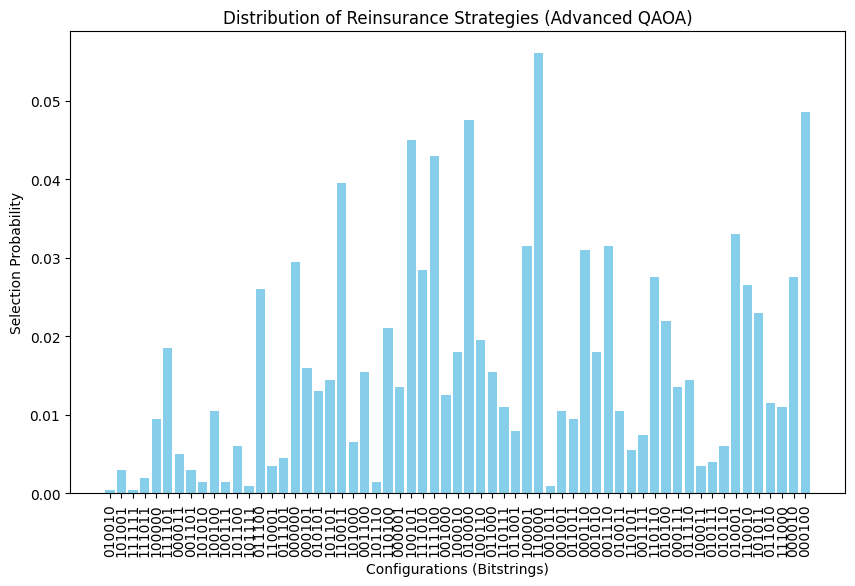

In [10]:
# -------------------------------
# QAOA execution
# -------------------------------

# Parameters 

p = 6 #number of layers 
K = 6 #Fourier parametrized - angles

use_ma_qaoa = True         # Multi-angle QAOA enabled / disabled
use_fourier = True         # Fourier parameterization enabled / disabled
mixer_type = "cat_map"      # Mixer type: "x", "fermionic", or "cat_map"
optimizer_type = "genetic"  # Classical optimizer: "qiskit" or "genetic"
qiskit_optimizer = "SPSA"   # Ignored if optimizer_type="genetic"

num_qubits = num_qubits    # One qubit per contract

# -------------------------
# Run QAOA optimization
# Returns optimal parameters (gamma/beta)
# -------------------------

optimal_params = optimize_qaoa(
    num_qubits=num_qubits,
    p=p,
    hamiltonian=hamiltonian,
    K=K,
    use_ma_qaoa=use_ma_qaoa,
    use_fourier=use_fourier,
    mixer_type=mixer_type,
    optimizer_type=optimizer_type,
    qiskit_optimizer=qiskit_optimizer,
    maxiter=50,       # Number of iterations / generations
    add_noise=False,   # Add stochastic noise to simulate hardware
    amplitude=10,     # Noise amplitude
    sigma=0.1,        # Standard deviation of Gaussian noise
    verbose=True      # Print progress
)

# -------------------------
# Unpack gamma and beta from the optimal parameters
# -------------------------

gamma_vec, beta_vec = unpack_params(optimal_params, num_qubits, p, hamiltonian,
                                   use_ma_qaoa, use_fourier, K=K)

# Ensure real floats (in case of complex numbers)
gamma_vec = [[float(np.real(g)) for g in layer] for layer in gamma_vec]
beta_vec  = [[float(np.real(b)) for b in layer] for layer in beta_vec]

# -------------------------
# Build the QAOA quantum circuit
# -------------------------

qc = build_qaoa_circuit(num_qubits, p, hamiltonian, gamma_vec, beta_vec, mixer_type)
qc.measure_all()  # Add measurement to all qubits

# -------------------------
# Simulate the circuit using the Aer simulator
# -------------------------

backend = AerSimulator()
result = backend.run(qc, shots=2000).result()
counts = result.get_counts()                  
print(counts)

# ---------------------------------------------------------
# Analysis and simulation 
# ---------------------------------------------------------

states = list(counts.keys())
probs = [v / sum(counts.values()) for v in counts.values()] # Normalization to %
plt.figure(figsize=(10, 6))
plt.bar(states, probs, color='skyblue')
plt.xlabel("Configurations (Bitstrings)")
plt.ylabel("Selection Probability")
plt.title("Distribution of Reinsurance Strategies (Advanced QAOA)")
plt.xticks(rotation=90)
plt.show()

--- 

Cool, now you have Quantum optimised contract portolios! Let's select the very bests of them:

In [11]:
top_5_raw = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:5]

print(f"\n" + "="*60)
print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
print("-" * 60)

for i, (bitstring, count) in enumerate(top_5_raw):
    # Calcul de la probabilité
    prob = (count / sum(counts.values())) * 100
    
    # Inversion du bitstring pour l'ordre métier (q0, q1, q2...)
    config = bitstring[::-1]
    
    # Calcul du capital libéré pour ce bitstring précis
    cap_total = sum(capital_relief[j] for j, bit in enumerate(config) if bit == '1')
    
    # Vérification de la cible S
    statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
    
    print(f"#{i+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

print("="*60)


RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 000011     |    5.6% |      2000.0 M€ | ✅ OK
#2    | 001000     |    4.9% |       500.0 M€ | ✅ OK
#3    | 000010     |    4.8% |       800.0 M€ | ✅ OK
#4    | 101001     |    4.5% |      1950.0 M€ | ✅ OK
#5    | 001111     |    4.3% |      2680.0 M€ | ✅ OK


As you can see, as we had to build our own list of contracts, we had some fun in choosing the capitals engaged. 

### 2. VQE algorithm

Now things are getting serious: it's the moment for the QAOA vs VQE fight you've been waiting for!

In [32]:
### INITIALIZATION FOR VQE
n_train = 20
risk_data = get_multi_risk_data()

# Paramètres de l'article arXiv:2504.16530
S = 100.0   # Cible de capital libéré (Target)
alpha = 5.0 # Importance de la contrainte de capital
gamma = 2.0 # Aversion au risque de queue (Tail Risk)

hamiltonian = construct_reinsurance_hamiltonian_pl(
    n=num_qubits,
    premiums=risk_data[0],
    expected_recoveries=risk_data[1],
    tail_cov=risk_data[2],
    S=S,
    alpha=alpha,
    capital_relief=risk_data[3],
    gamma=gamma)

optimizer_method = 'BFGS'
tol = 1e-4
num_layers = (2, 2) # (processing layers, encoding layers)
vqe_num_layers = [num_layers[0]+ num_layers[1], 0] #vqe only has processing layers

<class 'numpy.ndarray'>


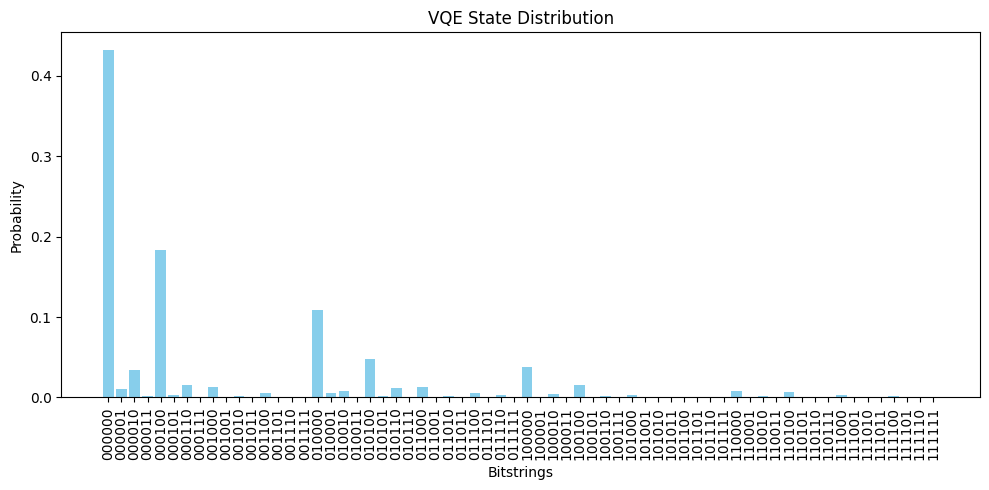

RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 000000     |   43.2% |         0.0 M€ | ❌ FAIL
#2    | 001000     |   18.3% |       500.0 M€ | ✅ OK
#3    | 000010     |   10.9% |       800.0 M€ | ✅ OK
#4    | 001010     |    4.8% |      1300.0 M€ | ✅ OK
#5    | 000001     |    3.9% |      1200.0 M€ | ✅ OK


In [33]:
### BACKEND FOR VQE
backend = FakeBrisbane()
dev = qml.device('qiskit.aer', wires = num_qubits, backend=backend)

### GET OPTIMAL PARAMETERS FOR VQE
optimal_angle = optimize_vqe(num_qubits, num_layers, risk_data, optimizer_method="BFGS", tol=1e-4,S=S, alpha=alpha, gamma=gamma)

### BUILD AND RUN CIRCUIT WITH OPTIMAL PARAMETERS
@qml.set_shots(2000)
@qml.qnode(dev, diff_method="finite-diff")
def opt_vqe_circuit(proc_params, n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma):

    processing_layer(proc_params, range(n), n, vqe_num_layers)
    ham = construct_reinsurance_hamiltonian_pl(n, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
    return qml.probs(wires=range(n))


### PLOT RESULTS
probs = opt_vqe_circuit(optimal_angle.reshape(num_layers[0] + num_layers[1], num_qubits, 2), num_qubits, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
print(type(probs))
bitstrings = [format(i, f'0{num_qubits}b') for i in range(2**num_qubits)]

# Plot histogram
plt.figure(figsize=(10, 5))
plt.bar(bitstrings, probs, color='skyblue')
plt.xlabel("Bitstrings")
plt.ylabel("Probability")
plt.title("VQE State Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Get top 5 indices sorted by probability
top5_idx = np.argsort(probs)[::-1][:5]

print("=" * 60)
print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
print("-" * 60)

for rank, idx in enumerate(top5_idx):
    bitstring = bitstrings[idx]
    prob = probs[idx] * 100
    config = bitstring[::-1]  # reverse for business order (q0, q1, ...)
    cap_total = sum(capital_relief[j] for j, bit in enumerate(config) if bit == '1')
    statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
    print(f"#{rank+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

print("=" * 60)

If you run this last cell a few times (which means with the same dataset), you will notice that the VQE does not converge to one specific value. While the distribution is quite point-like, it is never the same choice of contract that comes out.

This is where the meta-VQE comes into play. It will give an initial state already optimized to ease the convergence of the VQE. This VQE initialized with meta-VQE parameters is called opt-meta-VQE for optimized meta VQE.

In [44]:
### INITIALIZATION FOR META-VQE
n_train = 20
risk_data = get_multi_risk_data()
S = 100.0   # Target capital relief
alpha = 5.0 # Capital constraint importance
gamma = 2.0 # Tail risk aversion

hamiltonian = construct_reinsurance_hamiltonian_pl(
    n=num_qubits,
    premiums=risk_data[0],
    expected_recoveries=risk_data[1],
    tail_cov=risk_data[2],
    S=S,
    alpha=alpha,
    capital_relief=risk_data[3],
    gamma=gamma)

proc_params = np.random.uniform(0, np.pi, (num_layers[0], num_qubits, 2))
w_params = np.random.uniform(0, np.pi, (num_layers[1], num_qubits, 2))
enc_params = np.random.uniform(0, np.pi, (num_layers[1], num_qubits, 2))

gammas_train = np.linspace(0.5, 5.0, n_train) # Varying capital constraint importance

In [ ]:
### META-VQE OPTIMIZATION
trained_proc_params, trained_enc_params, trained_w_params = optimize_meta_VQE(
    proc_params=proc_params,
    enc_params=enc_params,
    w_params=w_params,
    num_qubits=num_qubits,
    insurance_parameters=risk_data,
    num_layers=num_layers,gammas_train=gammas_train,)

opt_w_params = trained_w_params.copy()

### optimization of the meta-VQE output for the specific gamma_sample
very_optimal_angle = optimize_opt_meta_VQE(
    trained_proc_params=trained_proc_params,
    trained_enc_params=trained_enc_params,
    trained_w_params=trained_w_params,
    num_qubits=num_qubits,
    insurance_parameters=risk_data,
    num_layers=num_layers,
    gamma_sample=gamma
)

### BACKEND FOR opt-meta-VQE
backend = FakeBrisbane()
dev = qml.device('qiskit.aer', wires = num_qubits, backend=backend)

@qml.set_shots(2000)
@qml.qnode(dev, diff_method="finite-diff")
def opt_meta_vqe_circuit(opt_proc_params, opt_enc_params, opt_w_params, num_qubits, premiums, expected_recoveries, tail_cov, capital_relief, num_layers, S=100.0, alpha=alpha, gamma=gamma):
    
    encoding_layer(opt_enc_params, opt_w_params, gamma, range(num_qubits), num_qubits, num_layers)
    
    processing_layer(opt_proc_params, range(num_qubits), num_qubits, num_layers)
    
    ham = construct_reinsurance_hamiltonian(num_qubits, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma)
    return qml.probs(wires=range(num_qubits))

# Recompute sizes from the actual trained shapes (don't rely on overwritten globals)
_proc_shape = trained_proc_params.shape   # (num_layers[0], num_qubits, 2)
_enc_shape  = trained_enc_params.shape    # (num_layers[1], num_qubits, 2)
_proc_size  = int(np.prod(_proc_shape))
_enc_size   = int(np.prod(_enc_shape))


# Split very_optimal_angle back into proc and enc parts
opt_proc_final = very_optimal_angle[:_proc_size].reshape(_proc_shape)
opt_enc_final  = very_optimal_angle[_proc_size: _proc_size + _enc_size].reshape(_enc_shape)

opt_probs = opt_meta_vqe_circuit(opt_proc_final, opt_enc_final, opt_w_params, num_qubits, premiums, expected_recoveries, tail_cov, capital_relief, num_layers, S, alpha_sample, gamma)

bitstrings = [format(i, f'0{num_qubits}b') for i in range(2**num_qubits)]

# Plot histogram
plt.figure(figsize=(10, 5))
plt.bar(bitstrings, opt_probs, color='skyblue')
plt.xlabel("Bitstrings")
plt.ylabel("Probability")
plt.title("VQE State Distribution (FakeBrisbane noise)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Get top 5 indices sorted by probability
top5_idx = np.argsort(opt_probs)[::-1][:5]

print("=" * 60)
print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
print("-" * 60)

for rank, idx in enumerate(top5_idx):
    bitstring = bitstrings[idx]
    prob = opt_probs[idx] * 100
    config = bitstring[::-1]  # reverse for business order (q0, q1, ...)
    cap_total = sum(capital_relief[j] for j, bit in enumerate(config) if bit == '1')
    statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
    print(f"#{rank+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

print("=" * 60)


Step   1: Loss = 15962654.989040
Step   2: Loss = 15962655.002850
Step   3: Loss = 15962654.979844
Step   4: Loss = 15962654.998796
Step   5: Loss = 15962654.990676
Step   6: Loss = 15962654.995608
Step   7: Loss = 15962654.996354
Step   8: Loss = 15962654.989155
Step   9: Loss = 15962654.999197
Step  10: Loss = 15962654.991679
Step  11: Loss = 15962654.987232
Step  12: Loss = 15962655.003853
Step  13: Loss = 15962654.994783
Step  14: Loss = 15962654.993248
Step  15: Loss = 15962654.994690
Step  16: Loss = 15962654.999718
Step  17: Loss = 15962655.014007
Step  18: Loss = 15962654.972484
Step  19: Loss = 15962655.006823
Step  20: Loss = 15962654.982464
Step  21: Loss = 15962654.997100
Step  22: Loss = 15962654.989237
Step  23: Loss = 15962654.989547
Step  24: Loss = 15962654.969211
Step  25: Loss = 15962654.954664
Step  26: Loss = 15962654.989040
Step  27: Loss = 15962654.972880
Step  28: Loss = 15962654.989040
Step  29: Loss = 15962654.984528
Step  30: Loss = 15962654.989040
Step  31: 

## 5️⃣ Global-warming sensitive models

This module transforms qualitative **IPCC (GIEC)** climate projections into quantitative actuarial inputs. We move from a **stationary risk model** (past = future) to a **non-stationary model** to account for the intensification of catastrophic events.

#### 1. Climate Forcing via RCP Scenarios
We define a **Severity Factor** ($\lambda$) based on the **Representative Concentration Pathways (RCP)**:
* **RCP 2.6 (Paris Agreement):** Rapid decarbonization; minimal impact on historical distributions.
* **RCP 4.5 (Intermediate):** Emissions peak around 2040; moderate increase in weather volatility.
* **RCP 8.5 (Business-as-Usual):** Worst-case scenario; maximum stress on natural catastrophe (NatCat) lines.

#### 2. Mathematical Hazard Intensification
The climate factor dynamically modifies the parameters of our underlying stochastic processes:
* **Windstorm Intensity:** We scale the **Scale Parameter** of the Weibull distribution ($+15\%$ per impact unit), shifting the entire distribution toward higher losses.
* **Flood Fat-Tails:** We decrease the **Shape Parameter ($\alpha$)** of the Pareto distribution. This "fattens" the tail, drastically increasing the probability of extreme, systemic floods.
* **Zoonotic Pandemic Risk:** Climate-driven habitat changes are modeled by increasing the **Poisson Intensity ($\lambda$)**, simulating more frequent global health shocks.



#### 3. Actuarial Impacts on Optimization
* **The Insurability Gap:** We simulate a market reality where `premiums` lag behind the real `expected_recoveries`, testing the portfolio's solvency under "under-priced" risk conditions.
* **Tail Correlation Convergence:** In extreme scenarios, the **Tail Covariance Matrix** becomes denser. The solver must account for the fact that different perils (Wind, Flood, Pandemic) tend to trigger simultaneously in a warming world.
* **Capital Efficiency:** The model tracks how the **Capital Relief** ($K_i$) effectiveness is eroded by the rising cost of risk, forcing the optimization algorithm to find more resilient contract combinations.

In [77]:
def get_climate_risk_data(n_sims=10000, scenario = "RCP2.6", horizon=2050):
    """
    Simulates climate impact on 6 risk lines and their 6 associated contracts.
    
    Scenarios: 
    - "RCP2.6" : Rapid transition (Low impact)
    - "RCP4.5" : Delayed transition (Moderate impact)
    - "RCP8.5" : Continuous emissions (Severe impact)
    """
    np.random.seed(42)
    
    # --- 1️⃣ CLIMATE SEVERITY FACTOR CALCULATION ---
    dt = max(0, horizon - 2024)
    # Scenario weight (arbitrary multipliers consistent with actuarial literature)
    severity_weights = {"RCP2.6": 0.5, "RCP4.5": 1.2, "RCP8.5": 3.0}
    impact_factor = (dt / 25) * severity_weights.get(scenario, 1.2)

    # --- 2️⃣ RISK GENERATION UNDER CLIMATE STRESS ---
    
    # Windstorm (Weibull): Increasing peak intensity
    # Increase the scale factor
    wind_scale = 40 * (1 + 0.15 * impact_factor)
    windstorm = np.random.weibull(1.5, n_sims) * wind_scale
    
    # Flood (Pareto): Increased flood frequency and severity (Heavier tail)
    # Decreasing alpha index => the tail becomes a "Fat Tail"
    flood_alpha = max(1.05, 1.2 - (0.05 * impact_factor))
    flood = (np.random.pareto(flood_alpha, n_sims) + 1) * 60
    
    # Cyber (Jump-Diffusion): Non-climatic, remains stable
    base_cyber = np.random.lognormal(2, 0.5, n_sims)
    cyber = base_cyber + np.random.poisson(0.01, n_sims) * 500 
    
    # Pandemic (Poisson-Peak): Increased zoonotic risk due to global warming
    pandemic_freq = 0.005 * (1 + 0.25 * impact_factor)
    pandemic = np.random.poisson(pandemic_freq, n_sims) * np.random.gamma(10, 100, n_sims)
    
    # Liability & Credit: Slight volatility increase due to macro instability
    liability = np.random.gamma(2, 20 * (1 + 0.05 * impact_factor), n_sims)
    credit = np.random.beta(0.5, 5, n_sims) * (200 * (1 + 0.05 * impact_factor))

    # Aggregated risk matrix
    risk_matrix = np.column_stack([windstorm, flood, cyber, pandemic, liability, credit])
    total_loss = np.sum(risk_matrix, axis=1)

    # --- 3️⃣ REINSURANCE TREATIES (6 Qubits) ---
    recoveries = np.zeros((n_sims, 6))

    # Q0: Property XS (Wind + Flood)
    recoveries[:, 0] = np.minimum(np.maximum(windstorm + flood - 150, 0), 800)
    # Q1: Cyber XS
    recoveries[:, 1] = np.minimum(np.maximum(cyber - 100, 0), 1000)
    # Q2: Quota Share (20% share of the whole portfolio)
    recoveries[:, 2] = total_loss * 0.20
    # Q3: Financial Lines XS
    recoveries[:, 3] = np.minimum(np.maximum(liability + credit - 60, 0), 400)
    # Q4: Global Stop-Loss (Low threshold)
    recoveries[:, 4] = np.minimum(np.maximum(total_loss - 250, 0), 1500)
    # Q5: Global Stop-Loss (High threshold)
    recoveries[:, 5] = np.minimum(np.maximum(total_loss - 500, 0), 3000)

    # --- 4️⃣ FINAL CALCULATIONS (Premiums, Expected Value, Tail) ---
    expected_rec = np.mean(recoveries, axis=0)
    
    # Tail Covariance (95th percentile)
    threshold = np.percentile(total_loss, 95)
    tail_cov = np.cov(recoveries[total_loss > threshold], rowvar=False)
    
    # Premiums increase slower than actual risk (insurability gap)
    # Maintain a fixed margin on the calculated expected recovery
    premiums = expected_rec * 1.3 
    
    # Capital Relief (unchanged for stable comparison)
    capital_relief = np.array([250, 300, 500, 180, 800, 1200])
    
    return premiums, expected_rec, tail_cov, capital_relief

Generation 1/50, Best Energy = 4318496.300294
Generation 2/50, Best Energy = 4318496.300294
Generation 3/50, Best Energy = 4318496.300294
Generation 4/50, Best Energy = 4318496.300294
Generation 5/50, Best Energy = 4318166.919328
Generation 6/50, Best Energy = 4318166.919328
Generation 7/50, Best Energy = 4318166.919328
Generation 8/50, Best Energy = 4318166.919328
Generation 9/50, Best Energy = 4318166.919328
Generation 10/50, Best Energy = 4318166.919328
Generation 11/50, Best Energy = 4318166.919328
Generation 12/50, Best Energy = 4318166.919328
Generation 13/50, Best Energy = 4318166.919328
Generation 14/50, Best Energy = 4318166.919328
Generation 15/50, Best Energy = 4318166.919328
Generation 16/50, Best Energy = 4318166.919328
Generation 17/50, Best Energy = 4268460.359332
Generation 18/50, Best Energy = 4268460.359332
Generation 19/50, Best Energy = 4268460.359332
Generation 20/50, Best Energy = 4268460.359332
Generation 21/50, Best Energy = 4268460.359332
Generation 22/50, Best

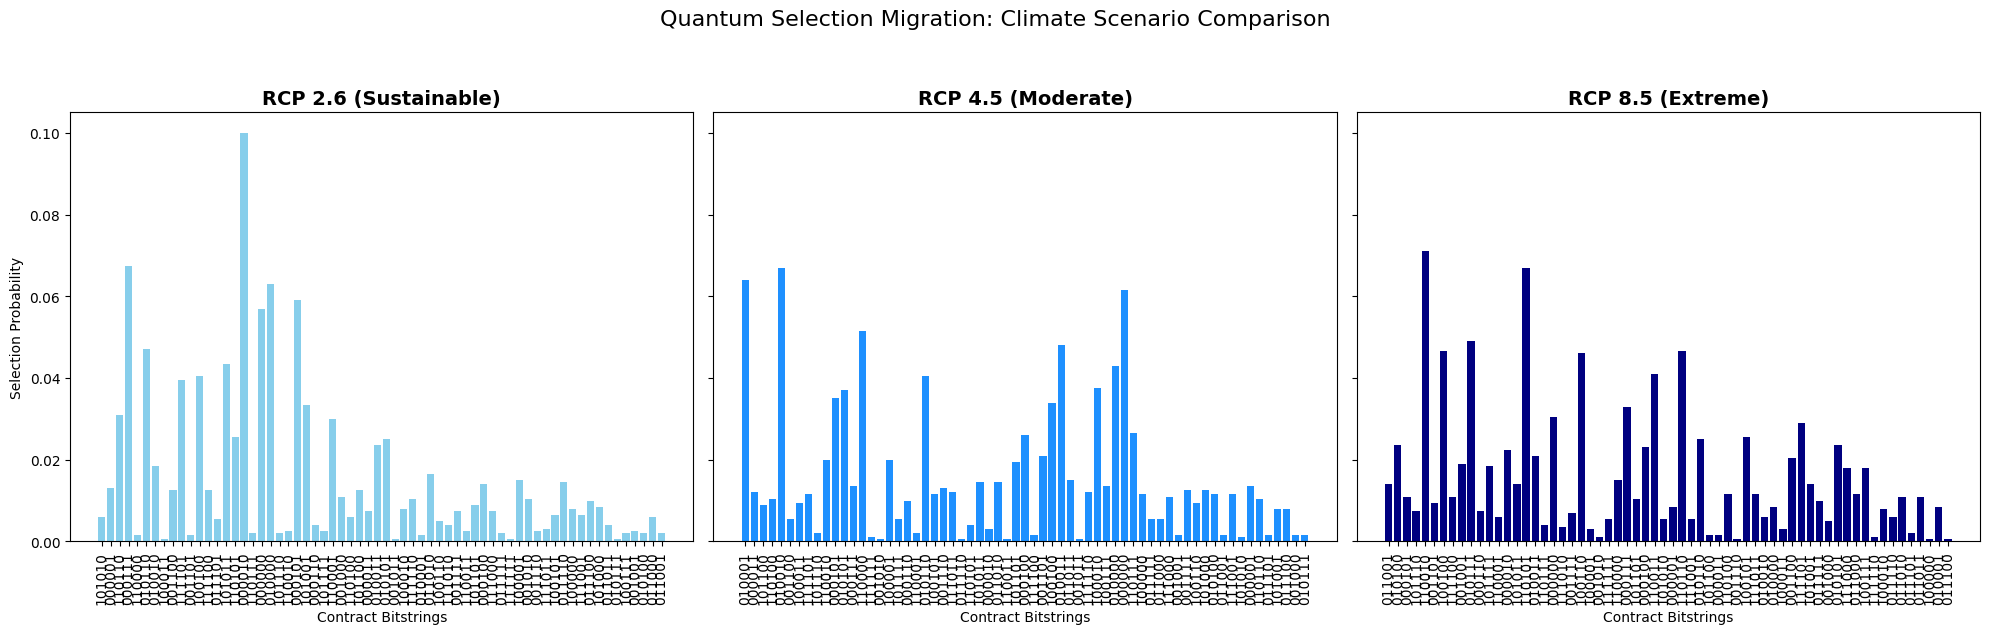

In [83]:
# ---------------------------------------------------------
# SCENARIO 1: RCP2.6
# ---------------------------------------------------------
scenario_26 = "RCP2.6"
P26, E26, Cov26, K26 = get_climate_risk_data(n_sims=10000, scenario=scenario_26, horizon=2050)

p = 6
K = 6
num_qubits = 6

hamiltonian26 = construct_reinsurance_hamiltonian(
    num_qubits, P26, E26, Cov26, S, alpha, K26, gamma
)

optimal_params26 = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian26, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=50, verbose=False
)

gamma_vec26, beta_vec26 = unpack_params(optimal_params26, num_qubits, p, hamiltonian26, use_ma_qaoa, use_fourier, K=K)
qc26 = build_qaoa_circuit(num_qubits, p, hamiltonian26, gamma_vec26, beta_vec26, mixer_type)
qc26.measure_all()
counts26 = backend.run(qc26, shots=2000).result().get_counts()

# ---------------------------------------------------------
# SCENARIO 2: RCP4.5
# ---------------------------------------------------------
scenario_45 = "RCP4.5"
P45, E45, Cov45, K45 = get_climate_risk_data(n_sims=10000, scenario=scenario_45, horizon=2050)

hamiltonian45 = construct_reinsurance_hamiltonian(
    num_qubits, P45, E45, Cov45, S, alpha, K45, gamma
)

optimal_params45 = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian45, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=50, verbose=False
)

gamma_vec45, beta_vec45 = unpack_params(optimal_params45, num_qubits, p, hamiltonian45, use_ma_qaoa, use_fourier, K=K)
qc45 = build_qaoa_circuit(num_qubits, p, hamiltonian45, gamma_vec45, beta_vec45, mixer_type)
qc45.measure_all()
counts45 = backend.run(qc45, shots=2000).result().get_counts()

# ---------------------------------------------------------
# SCENARIO 3: RCP8.5
# ---------------------------------------------------------
scenario_85 = "RCP8.5"
P85, E85, Cov85, K85 = get_climate_risk_data(n_sims=10000, scenario=scenario_85, horizon=2050)

hamiltonian85 = construct_reinsurance_hamiltonian(
    num_qubits, P85, E85, Cov85, S, alpha, K85, gamma
)

optimal_params85 = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian85, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=50, verbose=False
)

gamma_vec85, beta_vec85 = unpack_params(optimal_params85, num_qubits, p, hamiltonian85, use_ma_qaoa, use_fourier, K=K)
qc85 = build_qaoa_circuit(num_qubits, p, hamiltonian85, gamma_vec85, beta_vec85, mixer_type)
qc85.measure_all()
counts85 = backend.run(qc85, shots=2000).result().get_counts()

# ---------------------------------------------------------
# FINAL VISUALIZATION: 3 SUBPLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
all_results = [counts26, counts45, counts85]
titles = ["RCP 2.6 (Sustainable)", "RCP 4.5 (Moderate)", "RCP 8.5 (Extreme)"]
colors = ['skyblue', 'dodgerblue', 'navy']

for i, counts in enumerate(all_results):
    # Sort and normalize for plotting
    states = list(counts.keys())
    probs = [v / sum(counts.values()) for v in counts.values()]
    
    axes[i].bar(states, probs, color=colors[i])
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Contract Bitstrings")
    axes[i].tick_params(axis='x', rotation=90)
    if i == 0:
        axes[i].set_ylabel("Selection Probability")

plt.suptitle("Quantum Selection Migration: Climate Scenario Comparison", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

--- 

Cool, now you have Climate - change Quantum optimised contract portolios! Let's select the very bests of them:


 SCENARIO: RCP2.6
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 010000     |   10.0% |       300.0 M€ | ✅ OK
#2    | 111000     |    6.8% |      1050.0 M€ | ✅ OK
#3    | 000010     |    6.3% |       800.0 M€ | ✅ OK
#4    | 101000     |    5.9% |       750.0 M€ | ✅ OK
#5    | 000000     |    5.7% |         0.0 M€ | ❌ FAIL

 SCENARIO: RCP4.5
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 010010     |    6.7% |      1100.0 M€ | ✅ OK
#2    | 100010     |    6.4% |      1050.0 M€ | ✅ OK
#3    | 000000     |    6.2% |         0.0 M€ | ❌ FAIL
#4    | 000011     |    5.1% |      2000.0 M€ | ✅ OK
#5    | 110010     |    4.8% |      1350.0 M€ | ✅ OK

 SCENARIO: RCP8.5
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 010011     |    7.1% |      2300.0 M€ | ✅

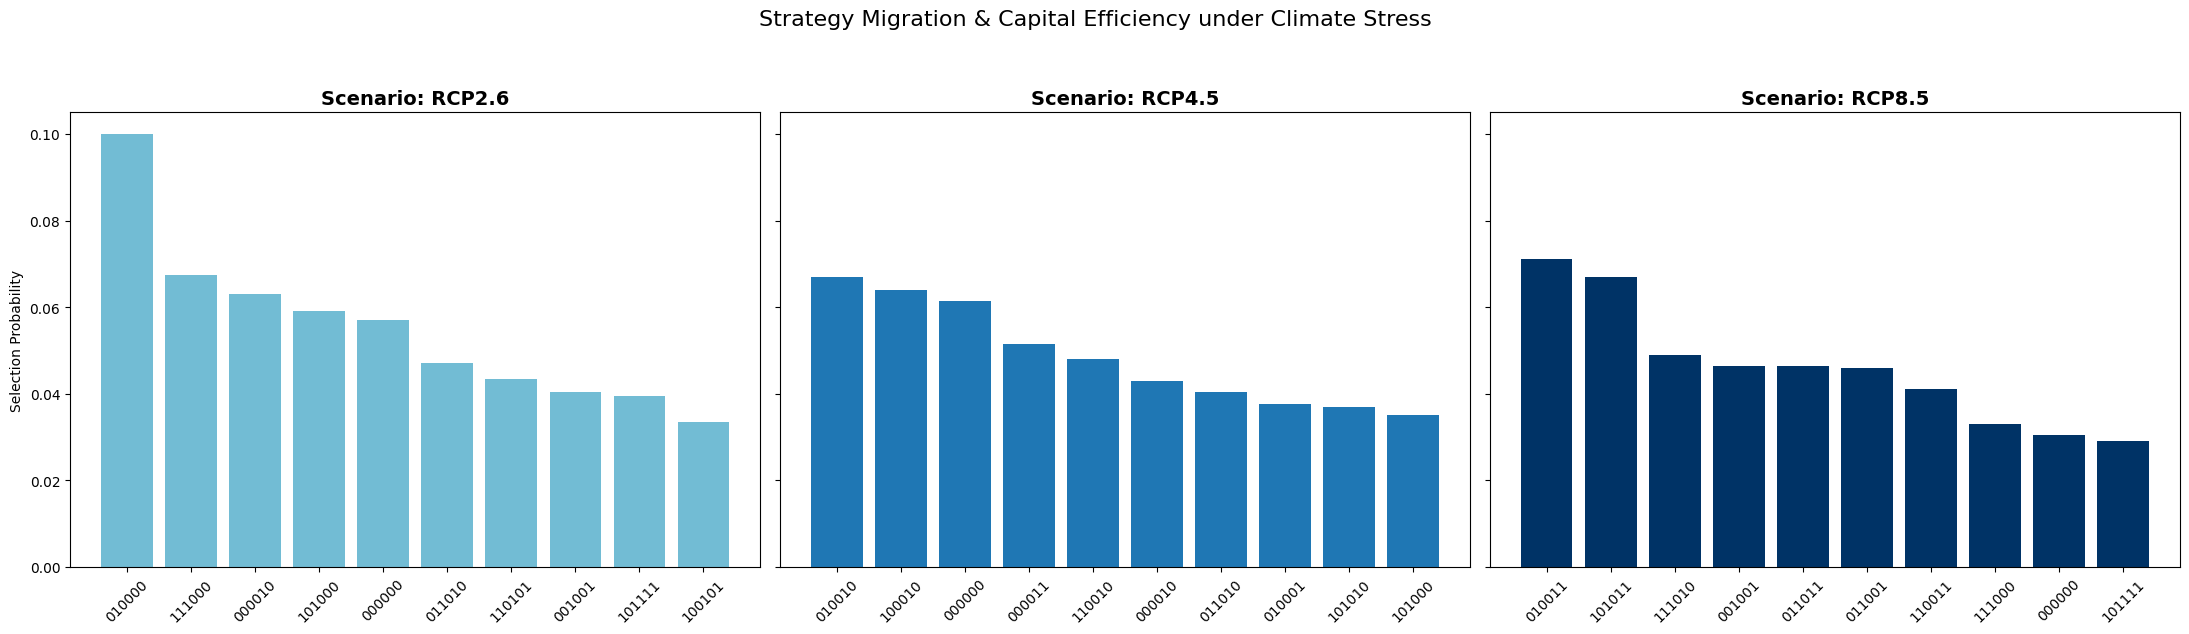

In [84]:
all_results = [
    (scenario_26, counts26, K26),
    (scenario_45, counts45, K45),
    (scenario_85, counts85, K85)
]

# Create Figure for Subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
colors = ['#72bcd4', '#1f77b4', '#003366']

for idx, (sc_name, counts, cap_relief_sc) in enumerate(all_results):
    
    # --- 1. YOUR EXACT PRINT LOGIC ---
    top_5_raw = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:5]

    print(f"\n" + "="*60)
    print(f" SCENARIO: {sc_name}")
    print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
    print("-" * 60)

    for i, (bitstring, count) in enumerate(top_5_raw):
        # Probability calculation
        prob = (count / sum(counts.values())) * 100
        
        # Business bitstring order (q0, q1, q2...)
        config = bitstring[::-1]
        
        # Capital relief for this specific bitstring
        cap_total = sum(cap_relief_sc[j] for j, bit in enumerate(config) if bit == '1')
        
        # S Target verification
        statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
        
        print(f"#{i+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

    print("="*60)

    # --- 2. SUBPLOT VISUALIZATION ---
    # Take top 10 for the graph to avoid clutter
    top_10_plot = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
    states_plot = [k[::-1] for k in top_10_plot.keys()] # Order q0, q1...
    probs_plot = [v / sum(counts.values()) for v in top_10_plot.values()]

    axes[idx].bar(states_plot, probs_plot, color=colors[idx])
    axes[idx].set_title(f"Scenario: {sc_name}", fontsize=14, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    if idx == 0:
        axes[idx].set_ylabel("Selection Probability")

plt.suptitle("Strategy Migration & Capital Efficiency under Climate Stress", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 6️⃣ Quantum-Enhanced Financial Asset Protection

### Optimizing Reinsurance for Systemic Market Risks
In a landscape defined by economic volatility and inflationary pressure, traditional insurance models often fail to capture the systemic nature of financial shocks. This project implements an **Advanced QAOA (Quantum Approximate Optimization Algorithm)** to solve the high-dimensional combinatorial challenge of **Financial Reinsurance Portfolio Selection**.

#### 🎯 The Strategic Shift
We pivot from a "Damage-Based" model (Fire, Storm) to a **Balance Sheet Protection** model. Here, we are not insuring buildings, but rather the **Asset side of the corporation** against market crashes, systemic defaults, and liquidity crises.



#### 🛠️ Core Innovation: The Stochastic Financial Universe
Our model generates a multi-peril "Financial Universe" using advanced stochastic processes to simulate real-world market behavior:
* **Equity Crashes:** Modeled via **Jump-Diffusion** to capture "Black Swan" events.
* **Credit Volatility:** Modeled via **Beta Distributions** to simulate default clusters.
* **Inflationary Stress:** A non-stationary approach where CPI increases drive interest rate shocks and asset devaluations.



#### ⚖️ The Quantum Advantage
By encoding these financial constraints into a **Hamiltonian**, the QAOA explores $2^n$ possible contract combinations to find the "Global Minimum" of risk. The solver identifies strategies that:
1. **Minimize Tail Covariance:** Ensuring the company survives correlated market sell-offs.
2. **Maximize Capital Efficiency:** Freeing up regulatory capital under **Solvency II** frameworks.
3. **Adapt Dynamically:** Seamlessly migrating the optimal strategy as we move from a "Low Inflation" to a "Stagflation" regime.

In [141]:
import numpy as np

def get_financial_risk_data(n_sims=50000): 
    """
    Standard Financial Risk Universe for Asset Protection.
    Focuses on Market Crashes, Defaults, and Liquidity.
    """
    # Force seed to ensure Hamiltonian consistency across runs
    np.random.seed(42) 
    
    # --- 1️⃣ GENERATING THE FINANCIAL RISK UNIVERSE ---
    
    # 1. Equity Market Crash (Jump-Diffusion)
    # Brownian motion + 1% chance of a massive systemic "Jump"
    base_mkt = np.random.normal(0.07, 0.15, n_sims)
    jumps = np.random.poisson(0.01, n_sims) * -0.40  
    equity_loss = np.maximum(-(base_mkt + jumps) * 1000, 0) # Loss in M€
    
    # 2. Credit Default (Beta Distribution)
    # Simulates clusters of corporate bond defaults
    credit_loss = np.random.beta(2, 40, n_sims) * 800 
    
    # 3. Interest Rate Shock (Lognormal)
    # Impacts fixed-income asset valuations
    rate_shock = np.random.lognormal(0.5, 0.8, n_sims) * 20
    
    # 4. FX / Currency Shock (Pareto)
    # Heavy-tailed devaluation of foreign investment holdings
    fx_loss = (np.random.pareto(1.5, n_sims)) * 30
    
    # 5. Liquidity Squeeze (Gamma)
    # Cost of emergency capital during market freezes
    liquidity_cost = np.random.gamma(2, 15, n_sims)
    
    # 6. Counterparty Risk (Poisson)
    # Sudden failure of a major financial partner
    counterparty_loss = np.random.poisson(0.005, n_sims) * 500

    # Total aggregate loss on the Asset Portfolio
    risk_matrix = np.column_stack([equity_loss, credit_loss, rate_shock, fx_loss, liquidity_cost, counterparty_loss])
    total_loss = np.sum(risk_matrix, axis=1)

    # --- 2️⃣ CONSTRUCTING FINANCIAL PROTECTION TREATIES (6 Qubits) ---
    recoveries = np.zeros((n_sims, 6))

    # Q0: Market-Link XS (Equity + FX) - Hedge against global downturns
    recoveries[:, 0] = np.minimum(np.maximum(equity_loss + fx_loss - 200, 0), 1000)
    
    # Q1: Credit Wrap (Credit + Counterparty) - Protects debt portfolio
    recoveries[:, 1] = np.minimum(np.maximum(credit_loss + counterparty_loss - 150, 0), 800)
    
    # Q2: Systematic Quota Share (QS) - 20% flat share of all risks
    recoveries[:, 2] = total_loss * 0.20
    
    # Q3: Macro Hedge (Rate Shock + Liquidity) - Protects against monetary shifts
    recoveries[:, 3] = np.minimum(np.maximum(rate_shock + liquidity_cost - 50, 0), 300)
    
    # Q4: Portfolio Stop-Loss (Low threshold) - Broad capital protection
    recoveries[:, 4] = np.minimum(np.maximum(total_loss - 300, 0), 1500)
    
    # Q5: Extreme Tail Stop-Loss (High threshold) - "Black Swan" protection
    recoveries[:, 5] = np.minimum(np.maximum(total_loss - 600, 0), 5000)

    # --- 3️⃣ FINAL PARAMETER CALCULATIONS ---
    # Expected recoveries (Average value)
    expected_rec = np.mean(recoveries, axis=0)
    
    # Tail Covariance Matrix (95th percentile threshold)
    threshold = np.percentile(total_loss, 95)
    tail_events_mask = total_loss > threshold
    tail_cov = np.cov(recoveries[tail_events_mask], rowvar=False)
    
    # Pricing: Technical price with 40% margin for systemic risk
    premiums = expected_rec * 1.4 
    
    # Capital Relief: High values for Solvency II market risk transfer
    capital_relief = np.array([500, 400, 600, 300, 1200, 2000])
    
    return premiums, expected_rec, tail_cov, capital_relief

In [142]:
# Contracts - related data

premiums, expected_recoveries, tail_cov, capital_relief = get_financial_risk_data()

# Insurer forecasts data

S, alpha, gamma = 100, 0.8, 2.0

# Initialisation 

num_qubits = 6

# -------------------------------
# Construction of the hamiltonian 
# -------------------------------

hamiltonian = construct_reinsurance_hamiltonian(
    num_qubits, premiums, expected_recoveries, tail_cov, S, alpha, capital_relief, gamma
)

Generation 1/50, Best Energy = 4307925.327302
Generation 2/50, Best Energy = 3865378.758582
Generation 3/50, Best Energy = 3865378.758582
Generation 4/50, Best Energy = 3865378.758582
Generation 5/50, Best Energy = 3865378.758582
Generation 6/50, Best Energy = 3865378.758582
Generation 7/50, Best Energy = 3865378.758582
Generation 8/50, Best Energy = 3710939.666127
Generation 9/50, Best Energy = 3710939.666127
Generation 10/50, Best Energy = 3710939.666127
Generation 11/50, Best Energy = 3710939.666127
Generation 12/50, Best Energy = 3710939.666127
Generation 13/50, Best Energy = 3710939.666127
Generation 14/50, Best Energy = 3710939.666127
Generation 15/50, Best Energy = 3710939.666127
Generation 16/50, Best Energy = 3710939.666127
Generation 17/50, Best Energy = 3710939.666127
Generation 18/50, Best Energy = 3710939.666127
Generation 19/50, Best Energy = 3710939.666127
Generation 20/50, Best Energy = 3710939.666127
Generation 21/50, Best Energy = 3330312.493348
Generation 22/50, Best

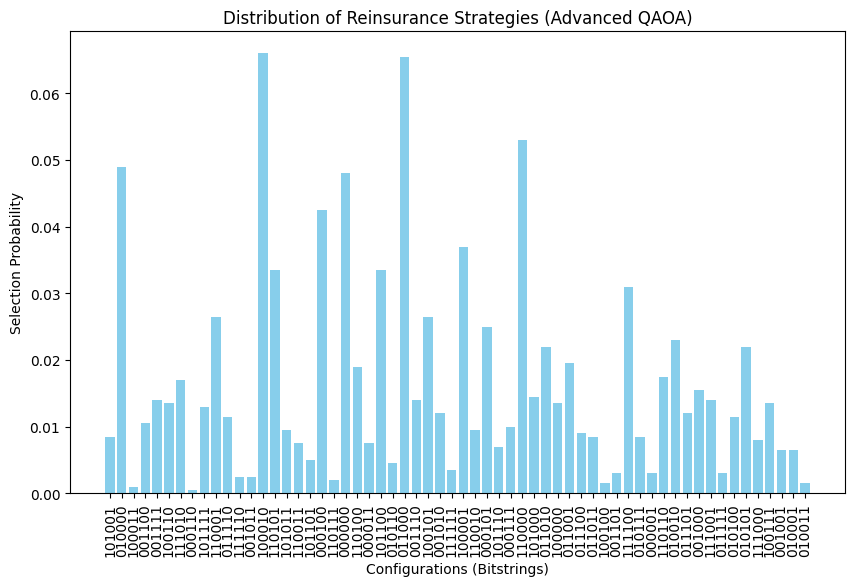

In [143]:
# -------------------------------
# QAOA execution
# -------------------------------

# Parameters 

p = 6 #number of layers 
K = 6 #Fourier parametrized - angles

use_ma_qaoa = True         # Multi-angle QAOA enabled / disabled
use_fourier = True         # Fourier parameterization enabled / disabled
mixer_type = "cat_map"      # Mixer type: "x", "fermionic", or "cat_map"
optimizer_type = "genetic"  # Classical optimizer: "qiskit" or "genetic"
qiskit_optimizer = "SPSA"   # Ignored if optimizer_type="genetic"

num_qubits = num_qubits    # One qubit per contract

# -------------------------
# Run QAOA optimization
# Returns optimal parameters (gamma/beta)
# -------------------------

optimal_params = optimize_qaoa(
    num_qubits=num_qubits,
    p=p,
    hamiltonian=hamiltonian,
    K=K,
    use_ma_qaoa=use_ma_qaoa,
    use_fourier=use_fourier,
    mixer_type=mixer_type,
    optimizer_type=optimizer_type,
    qiskit_optimizer=qiskit_optimizer,
    maxiter=50,       # Number of iterations / generations
    add_noise=False,   # Add stochastic noise to simulate hardware
    amplitude=10,     # Noise amplitude
    sigma=0.1,        # Standard deviation of Gaussian noise
    verbose=True      # Print progress
)

# -------------------------
# Unpack gamma and beta from the optimal parameters
# -------------------------

gamma_vec, beta_vec = unpack_params(optimal_params, num_qubits, p, hamiltonian,
                                   use_ma_qaoa, use_fourier, K=K)

# Ensure real floats (in case of complex numbers)
gamma_vec = [[float(np.real(g)) for g in layer] for layer in gamma_vec]
beta_vec  = [[float(np.real(b)) for b in layer] for layer in beta_vec]

# -------------------------
# Build the QAOA quantum circuit
# -------------------------

qc = build_qaoa_circuit(num_qubits, p, hamiltonian, gamma_vec, beta_vec, mixer_type)
qc.measure_all()  # Add measurement to all qubits

# -------------------------
# Simulate the circuit using the Aer simulator
# -------------------------

backend = AerSimulator()
result = backend.run(qc, shots=2000).result()
counts = result.get_counts()                  
print(counts)

# ---------------------------------------------------------
# Analysis and simulation 
# ---------------------------------------------------------

states = list(counts.keys())
probs = [v / sum(counts.values()) for v in counts.values()] # Normalization to %
plt.figure(figsize=(10, 6))
plt.bar(states, probs, color='skyblue')
plt.xlabel("Configurations (Bitstrings)")
plt.ylabel("Selection Probability")
plt.title("Distribution of Reinsurance Strategies (Advanced QAOA)")
plt.xticks(rotation=90)
plt.show()

In [144]:
top_5_raw = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:5]

print(f"\n" + "="*60)
print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
print("-" * 60)

for i, (bitstring, count) in enumerate(top_5_raw):
    # Calcul de la probabilité
    prob = (count / sum(counts.values())) * 100
    
    # Inversion du bitstring pour l'ordre métier (q0, q1, q2...)
    config = bitstring[::-1]
    
    # Calcul du capital libéré pour ce bitstring précis
    cap_total = sum(capital_relief[j] for j, bit in enumerate(config) if bit == '1')
    
    # Vérification de la cible S
    statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
    
    print(f"#{i+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

print("="*60)


RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 010001     |    6.6% |      2400.0 M€ | ✅ OK
#2    | 000110     |    6.6% |      1500.0 M€ | ✅ OK
#3    | 000011     |    5.3% |      3200.0 M€ | ✅ OK
#4    | 000010     |    4.9% |      1200.0 M€ | ✅ OK
#5    | 000000     |    4.8% |         0.0 M€ | ❌ FAIL


## 7️⃣ Inflationary Stress Methodology: From Macro-Scenarios to Tail Risk

This module transforms qualitative **Macro-Economic Forecasts** into quantitative actuarial inputs. We shift from a **stable price regime** to a **non-stationary volatility model** to account for the erosion of asset values and the explosion of systemic liabilities during inflationary spikes.

#### 1. Macro-Economic Forcing via Inflation Regimes
We define an **Inflationary Pressure Factor** ($\lambda$) based on three distinct economic regimes:
* **Low Inflation (Stagnation):** Annual CPI between 1-2%. Assets remain stable; credit spreads are narrow; minimal impact on historical loss distributions.
* **Moderate Inflation:** Annual CPI between 3-5%. Normal market cycles; moderate increase in interest rate volatility.
* **High Inflation (Stagflation):** CPI above 10%. Worst-case scenario; aggressive interest rate shocks combined with massive equity drawdowns and systemic credit defaults.

[Image of a graph showing the impact of inflation on different financial asset classes like stocks, bonds, and commodities]

#### 2. Mathematical Hazard Intensification
The inflation factor dynamically modifies the parameters of the underlying financial stochastic processes:
* **Equity Market Drawdown:** We increase the **Poisson Intensity** of the Jump-Diffusion process. High inflation destabilizes multiples, leading to more frequent "Black Swan" market crashes.
* **Credit Default Clusters:** We shift the **Beta Distribution** parameters. As real interest rates rise, corporate solvency drops, "fattening" the tail of credit default losses.
* **Interest Rate Shocks:** We scale the **Lognormal Volatility** of interest rate movements, simulating the aggressive central bank reactions typical of high-inflation environments.

[Image of a probability density function shift due to inflation showing heavier tails and higher extremes]

#### 3. Actuarial & Financial Impacts on Optimization
* **The "Silent" Insurability Gap:** We simulate a lag where `premiums` are eroded by inflation while `recoveries` (linked to nominal asset values) explode, testing the fund's real-terms solvency.
* **Market Contagion (Correlation Convergence):** In high-inflation regimes, the **Tail Covariance Matrix** becomes denser. Perils that were once independent (Equity vs. Credit) show high systemic correlation as all asset classes sell off simultaneously.
* **Capital Efficiency Migration:** The model monitors how **Capital Relief ($K_i$)** is outpaced by the rising nominal Value-at-Risk (VaR), forcing the QAOA solver to migrate toward more robust "Global Stop-Loss" protections.

[Image of a risk correlation matrix comparing a stable economic regime to a high-inflation scenario]

In [145]:
import numpy as np

def get_inflation_risk_data(n_sims=50000, scenario="Moderate"): 
    """
    Simulates Financial Risk Universe under different Inflationary Regimes.
    Scenarios: 'Low' (Stagnation), 'Moderate' (Target), 'High' (Stagflation)
    """
    # Fix seed for reproducibility of the Hamiltonian landscape
    np.random.seed(42) 
    
    # --- 1️⃣ INFLATION SEVERITY FACTOR ---
    # Multiplier reflecting the intensity of macro-economic stress
    inf_weights = {"Low": 0.8, "Moderate": 1.2, "High": 3.5}
    inf_factor = inf_weights.get(scenario, 1.2)
    
    # --- 2️⃣ GENERATING THE FINANCIAL RISK UNIVERSE ---
    
    # 1. Equity Market Crash (Jump-Diffusion)
    # Inflation destabilizes multiples. High inflation = higher crash probability.
    base_mkt = np.random.normal(0.07, 0.15, n_sims)
    jump_freq = 0.01 * (1 + 0.5 * inf_factor) # Jumps become more frequent with stress
    jumps = np.random.poisson(jump_freq, n_sims) * -0.40  
    equity_loss = np.maximum(-(base_mkt + jumps) * 1000, 0)
    
    # 2. Credit Default (Beta): High rates lead to more defaults
    # As inf_factor grows, the distribution shifts toward higher default rates
    credit_alpha = 2
    credit_beta = max(10, 40 / inf_factor) 
    credit_loss = np.random.beta(credit_alpha, credit_beta, n_sims) * 800 
    
    # 3. Interest Rate Shock (Lognormal): Linked to central bank hikes
    rate_scale = 20 * inf_factor
    rate_shock = np.random.lognormal(0.5, 0.8, n_sims) * rate_scale
    
    # 4. FX / Currency Shock (Pareto): High inflation devalues local currency
    fx_alpha = max(1.1, 1.5 - (0.1 * inf_factor)) # Lower alpha = fatter tail
    fx_loss = (np.random.pareto(fx_alpha, n_sims)) * 30
    
    # 5. Liquidity Squeeze (Gamma): Stagflation dries up capital markets
    liquidity = np.random.gamma(2, 15 * inf_factor, n_sims)
    
    # 6. Counterparty Risk (Poisson): Systemic failure risk rises
    counterparty = np.random.poisson(0.005 * inf_factor, n_sims) * 500

    # Aggregate Asset Loss
    risk_matrix = np.column_stack([equity_loss, credit_loss, rate_shock, fx_loss, liquidity, counterparty])
    total_loss = np.sum(risk_matrix, axis=1)

    # --- 3️⃣ FINANCIAL PROTECTION TREATIES (6 Qubits) ---
    recoveries = np.zeros((n_sims, 6))

    # Q0: Market-Link XS (Equity + FX)
    recoveries[:, 0] = np.minimum(np.maximum(equity_loss + fx_loss - 200, 0), 1000)
    # Q1: Credit Wrap (Credit + Counterparty)
    recoveries[:, 1] = np.minimum(np.maximum(credit_loss + counterparty - 150, 0), 800)
    # Q2: Systematic Quota Share (20%)
    recoveries[:, 2] = total_loss * 0.20
    # Q3: Macro Hedge (Rates + Liquidity)
    recoveries[:, 3] = np.minimum(np.maximum(rate_shock + liquidity - 50, 0), 300)
    # Q4: Portfolio Stop-Loss (Low attachment)
    recoveries[:, 4] = np.minimum(np.maximum(total_loss - 300, 0), 1500)
    # Q5: Extreme Tail Stop-Loss (High attachment)
    recoveries[:, 5] = np.minimum(np.maximum(total_loss - 600, 0), 5000)

    # --- 4️⃣ FINAL CALCULATIONS ---
    expected_rec = np.mean(recoveries, axis=0)
    
    # Tail Covariance Focus (95th percentile)
    threshold = np.percentile(total_loss, 95)
    tail_events_mask = total_loss > threshold
    tail_cov = np.cov(recoveries[tail_events_mask], rowvar=False)
    
    # Pricing: Technical price with 40% margin
    premiums = expected_rec * 1.4 
    
    # Capital Relief (K_i): Values per contract (M€)
    capital_relief = np.array([500, 400, 600, 300, 1200, 2000])

    return premiums, expected_rec, tail_cov, capital_relief

Generation 1/30, Best Energy = 4832757.551879
Generation 2/30, Best Energy = 4832757.551879
Generation 3/30, Best Energy = 4244014.996529
Generation 4/30, Best Energy = 4244014.996529
Generation 5/30, Best Energy = 4244014.996529
Generation 6/30, Best Energy = 4244014.996529
Generation 7/30, Best Energy = 4244014.996529
Generation 8/30, Best Energy = 4244014.996529
Generation 9/30, Best Energy = 4244014.996529
Generation 10/30, Best Energy = 4244014.996529
Generation 11/30, Best Energy = 4244014.996529
Generation 12/30, Best Energy = 4244014.996529
Generation 13/30, Best Energy = 4244014.996529
Generation 14/30, Best Energy = 4244014.996529
Generation 15/30, Best Energy = 4244014.996529
Generation 16/30, Best Energy = 4244014.996529
Generation 17/30, Best Energy = 4244014.996529
Generation 18/30, Best Energy = 4244014.996529
Generation 19/30, Best Energy = 4244014.996529
Generation 20/30, Best Energy = 4244014.996529
Generation 21/30, Best Energy = 4244014.996529
Generation 22/30, Best

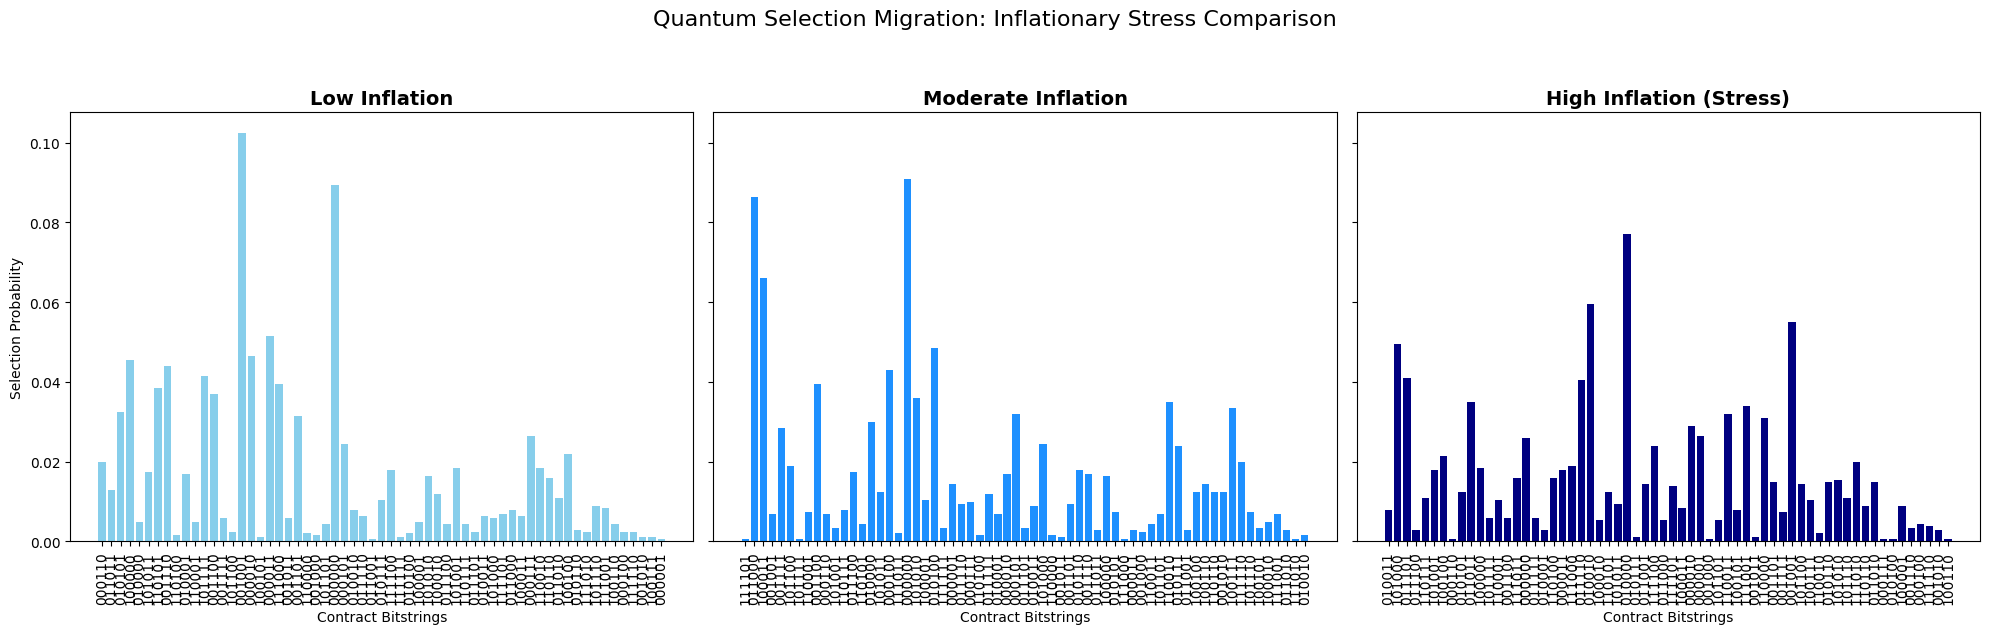

In [149]:
# ---------------------------------------------------------
# SCENARIO 1: LOW INFLATION (Stagnation)
# ---------------------------------------------------------
scenario_low = "Low"
P_low, E_low, Cov_low, K_low = get_inflation_risk_data(n_sims=10000, scenario=scenario_low)

p = 6
K = 6
num_qubits = 6

hamiltonian_low = construct_reinsurance_hamiltonian(
    num_qubits, P_low, E_low, Cov_low, S, alpha, K_low, gamma
)

optimal_params_low = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian_low, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=30, verbose=False
)

gamma_vec_low, beta_vec_low = unpack_params(optimal_params_low, num_qubits, p, hamiltonian_low, use_ma_qaoa, use_fourier, K=K)
qc_low = build_qaoa_circuit(num_qubits, p, hamiltonian_low, gamma_vec_low, beta_vec_low, mixer_type)
qc_low.measure_all()
counts_low = backend.run(qc_low, shots=2000).result().get_counts()

# ---------------------------------------------------------
# SCENARIO 2: MODERATE INFLATION
# ---------------------------------------------------------
scenario_mod = "Moderate"
P_mod, E_mod, Cov_mod, K_mod = get_inflation_risk_data(n_sims=10000, scenario=scenario_mod)

hamiltonian_mod = construct_reinsurance_hamiltonian(
    num_qubits, P_mod, E_mod, Cov_mod, S, alpha, K_mod, gamma
)

optimal_params_mod = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian_mod, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=30, verbose=False
)

gamma_vec_mod, beta_vec_mod = unpack_params(optimal_params_mod, num_qubits, p, hamiltonian_mod, use_ma_qaoa, use_fourier, K=K)
qc_mod = build_qaoa_circuit(num_qubits, p, hamiltonian_mod, gamma_vec_mod, beta_vec_mod, mixer_type)
qc_mod.measure_all()
counts_mod = backend.run(qc_mod, shots=2000).result().get_counts()

# ---------------------------------------------------------
# SCENARIO 3: HIGH INFLATION (Stagflation)
# ---------------------------------------------------------
scenario_high = "High"
P_high, E_high, Cov_high, K_high = get_inflation_risk_data(n_sims=10000, scenario=scenario_high)

hamiltonian_high = construct_reinsurance_hamiltonian(
    num_qubits, P_high, E_high, Cov_high, S, alpha, K_high, gamma
)

optimal_params_high = optimize_qaoa(
    num_qubits=num_qubits, p=p, hamiltonian=hamiltonian_high, K=K,
    use_ma_qaoa=use_ma_qaoa, use_fourier=use_fourier, mixer_type=mixer_type,
    optimizer_type=optimizer_type, maxiter=30, verbose=False
)

gamma_vec_high, beta_vec_high = unpack_params(optimal_params_high, num_qubits, p, hamiltonian_high, use_ma_qaoa, use_fourier, K=K)
qc_high = build_qaoa_circuit(num_qubits, p, hamiltonian_high, gamma_vec_high, beta_vec_high, mixer_type)
qc_high.measure_all()
counts_high = backend.run(qc_high, shots=2000).result().get_counts()

# ---------------------------------------------------------
# FINAL VISUALIZATION: 3 SUBPLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
all_results_counts = [counts_low, counts_mod, counts_high]
titles = ["Low Inflation", "Moderate Inflation", "High Inflation (Stress)"]
colors = ['skyblue', 'dodgerblue', 'navy']

for i, counts in enumerate(all_results_counts):
    # Standard sort for visualization
    states = list(counts.keys())
    # Applying the [::-1] reversed order for business logic display
    states_rev = [s[::-1] for s in states]
    probs = [v / sum(counts.values()) for v in counts.values()]
    
    axes[i].bar(states_rev, probs, color=colors[i])
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Contract Bitstrings")
    axes[i].tick_params(axis='x', rotation=90)
    if i == 0:
        axes[i].set_ylabel("Selection Probability")

plt.suptitle("Quantum Selection Migration: Inflationary Stress Comparison", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


 SCENARIO: Low
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 001001     |   10.2% |      2600.0 M€ | ✅ OK
#2    | 000000     |    8.9% |         0.0 M€ | ❌ FAIL
#3    | 000011     |    5.1% |      3200.0 M€ | ✅ OK
#4    | 000010     |    4.7% |      1200.0 M€ | ✅ OK
#5    | 100000     |    4.5% |       500.0 M€ | ✅ OK

 SCENARIO: Moderate
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 000000     |    9.1% |         0.0 M€ | ❌ FAIL
#2    | 011000     |    8.6% |      1000.0 M€ | ✅ OK
#3    | 100011     |    6.6% |      3700.0 M€ | ✅ OK
#4    | 010100     |    4.9% |       700.0 M€ | ✅ OK
#5    | 000100     |    4.3% |       300.0 M€ | ✅ OK

 SCENARIO: High
RANG  | BITSTRING  | PROBA    | CAPITAL LIBÉRÉ  | STATUT S
------------------------------------------------------------
#1    | 010000     |    7.7% |       400.0 M€ | ✅ OK

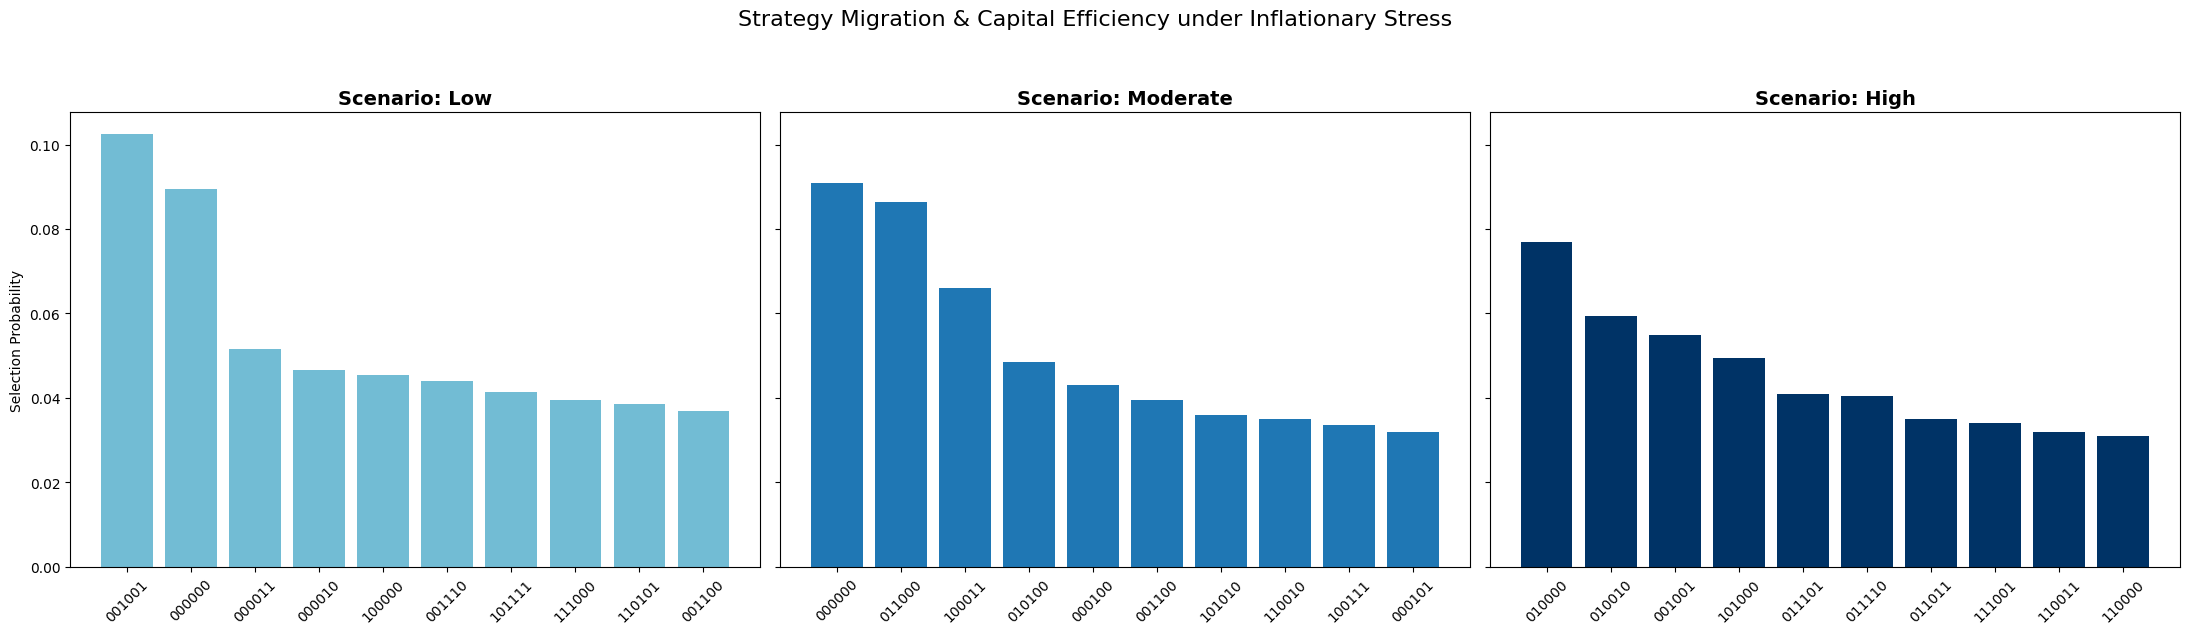

In [150]:
all_results = [
    (scenario_low, counts_low, K_low),
    (scenario_mod, counts_mod, K_mod),
    (scenario_high, counts_high, K_high)
]

# Create Figure for Subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
colors = ['#72bcd4', '#1f77b4', '#003366']

for idx, (sc_name, counts, cap_relief_sc) in enumerate(all_results):
    
    # --- 1. YOUR EXACT PRINT LOGIC ---
    top_5_raw = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:5]

    print(f"\n" + "="*60)
    print(f" SCENARIO: {sc_name}")
    print(f"{'RANG':<5} | {'BITSTRING':<10} | {'PROBA':<8} | {'CAPITAL LIBÉRÉ':<15} | {'STATUT S'}")
    print("-" * 60)

    for i, (bitstring, count) in enumerate(top_5_raw):
        # Probability calculation
        prob = (count / sum(counts.values())) * 100
        
        # Inversion du bitstring pour l'ordre métier (q0, q1, q2...)
        config = bitstring[::-1]
        
        # Calcul du capital libéré pour ce bitstring précis
        cap_total = sum(cap_relief_sc[j] for j, bit in enumerate(config) if bit == '1')
        
        # Vérification de la cible S
        statut_s = "✅ OK" if cap_total >= S else "❌ FAIL"
        
        print(f"#{i+1:<4} | {config:<10} | {prob:>6.1f}% | {cap_total:>11.1f} M€ | {statut_s}")

    print("="*60)

    # --- 2. SUBPLOT VISUALIZATION ---
    # Take top 10 for the graph to avoid clutter
    top_10_plot = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
    states_plot = [k[::-1] for k in top_10_plot.keys()] # Order q0, q1...
    probs_plot = [v / sum(counts.values()) for v in top_10_plot.values()]

    axes[idx].bar(states_plot, probs_plot, color=colors[idx])
    axes[idx].set_title(f"Scenario: {sc_name}", fontsize=14, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    if idx == 0:
        axes[idx].set_ylabel("Selection Probability")

plt.suptitle("Strategy Migration & Capital Efficiency under Inflationary Stress", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Thank you for your attention all along our notebook; the challenge was really interesting and was worth loosing some sleep!

## Kind regards from tre Quoblestone team ;)